In [2]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
from scipy.signal import savgol_filter



### What does the dataset look like 

In [14]:
path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
f = h5py.File(path, "r")

In [10]:
with h5py.File("/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/fightBouts.h5", "r") as f:
    fb = f["fight_bout_info"][:]

print(fb)

with h5py.File("/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/fightBouts.h5", "r") as f:
    print("FILE ATTRS:", dict(f.attrs))
    for k in f.keys():
        print(k, "ATTRS:", dict(f[k].attrs))

[[     0 643500 805400 161900]
 [     1 493700 655400 161700]
 [     2  31500 175400 143900]
 [     3 331300 436400 105100]
 [     5 448500 559400 110900]
 [     7 505500 553400  47900]
 [     8 181500 256200  74700]
 [     8 274700 334400  59700]
 [    10  19700  79400  59700]
 [    11 214900 280400  65500]
 [    12 142500 226400  83900]
 [    12 262500 343400  80900]
 [    13 694500 745600  51100]
 [    14   7700  61800  54100]
 [    15  13500 184400 170900]
 [    18 388700 556400 167700]
 [    19 526700 571200  44500]
 [    20  40900 169600 128700]]
FILE ATTRS: {}
exps_fight_info ATTRS: {}
fight_bout_info ATTRS: {}
fight_bout_info_noDurThresh ATTRS: {}
refined_exps_fight_info ATTRS: {}


In [12]:
def print_h5(name, obj):
    print(name)

with h5py.File(path, "r") as f:
    f.visititems(print_h5)

idtracker_sleap_assignment_nothresh_costs
interp_info
methodIdxs
pass2_added_data_info_from_assigning_remaining_detections
pass2_added_data_info_from_ids
positions_imageCoordinates
reg_thresh_removal_info
registration_costs
savgol_info
size_thresh_removal_info
successful_tracking
tracks_3D_raw
tracks_3D_smooth
tracks_available_post_initial_id_assignments
tracks_dim_names
tracks_imCoords_raw


In [15]:
dset = f["tracks_3D_smooth"]
dset.shape

(501943, 2, 3, 3)

In [16]:
f["tracks_dim_names"][:]

array([b'numFrames', b'numFish', b'numBodyPoints', b'XYZ'], dtype=object)

In [17]:
X = f["tracks_3D_smooth"]
fish_nan = np.isnan(X).any(axis=(2,3))  

fish_nan.shape
fish_nan.sum(axis=0)

array([8021, 7986])

In [18]:
valid_frames = ~fish_nan.any(axis=1)  # both fish present
valid_frames.mean()

np.float64(0.9792845004313239)

So "tracks_3D_smooth" consists of smoothed out datapoints, dimensions (T,f,bp,xyz), (501943, 2, 3, 3), 98% of frames are both fish fully present, we only have positions need to calculate the rest, fps = 100, dt = 0.01


### Single fish trajectories

median speed 7.2207962074306575 cm/s
[6.73337888 6.32934737 5.92531586 5.52128435 4.63883348]


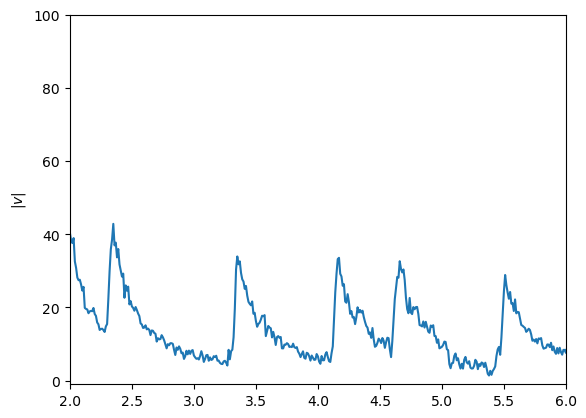

In [19]:
dt = 1/100
pec = X[:,:,1,:] # take middle body point, (T,f,xyz)
pec_fish0 = pec[:,0,:] # (T,xyz) fish 1
pec_fish1 = pec[:,1,:] # (T,xyz) fish 2

velocity_fish0 = (pec_fish0[1:,:] - pec_fish0[:-1,:])/dt # forward difference 
velocity_fish1 = (pec_fish1[1:,:] - pec_fish1[:-1,:])/dt
speed_fish0 = np.linalg.norm(velocity_fish0, axis=1)
speed_fish1 = np.linalg.norm(velocity_fish1, axis=1)
print('median speed',np.nanmedian(speed_fish0), 'cm/s')
t = np.arange(len(speed_fish0))*dt
plt.plot(t,speed_fish0)
plt.ylabel(r'$|v|$')
plt.xlim(2,6)
plt.ylim(-1,100)
print(velocity_fish0[:5,0])

(0.0, 100.0)

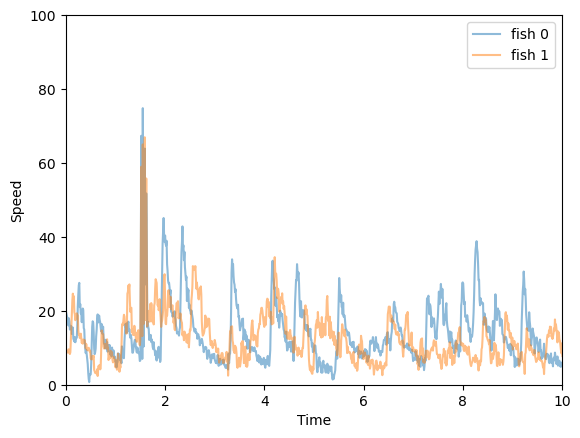

In [20]:
plt.plot(t, speed_fish0,alpha = 0.5, label="fish 0")
plt.plot(t, speed_fish1,alpha = 0.5 ,label="fish 1")
plt.legend()
plt.xlim(0,10)
plt.xlabel('Time')
plt.ylabel('Speed')
plt.ylim(0,100)

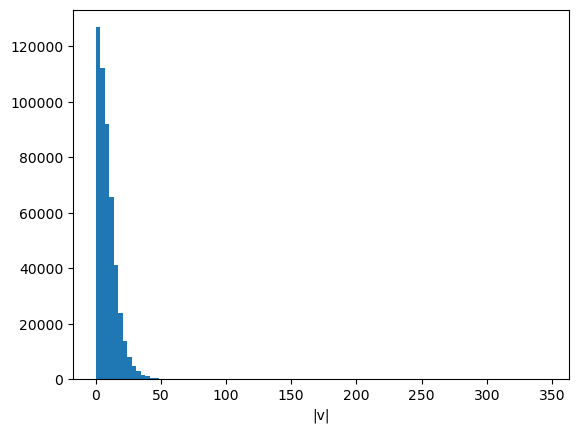

In [21]:
plt.hist(speed_fish0, bins=100)
plt.xlabel('|v|')
plt.show()

In [22]:
mask = ~np.isnan(speed_fish0) & ~np.isnan(speed_fish1)
np.corrcoef(speed_fish0[mask], speed_fish1[mask])[0,1]

np.float64(0.41947307697025604)

#### Orientation

In [23]:
head_fish0 = X[:, 0, 0, :]
head_fish1 = X[:, 1, 0, :]

vector_fish0 = (head_fish0 - pec_fish0)
orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

vector_fish1 = (head_fish1 - pec_fish1)
orientation_fish1 = vector_fish1/np.linalg.norm(vector_fish1, axis=1, keepdims=True)

(501943,)


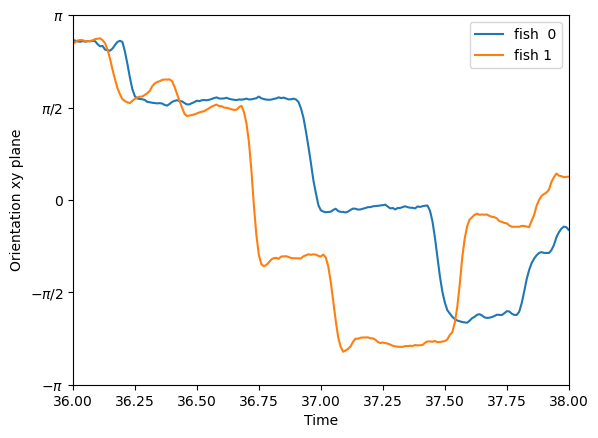

In [24]:
theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])
print(theta0.shape)
theta1 = np.arctan2(orientation_fish1[:, 1], orientation_fish1[:, 0])

dt = 0.01

t = np.arange(len(theta0))*dt
plt.plot(t, theta0, label= 'fish  0')
plt.plot(t,theta1, label = 'fish 1')
plt.yticks(
    [-np.pi, -np.pi/2, 0, np.pi/2, np.pi],
    [r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"]
)
#plt.xlim(13,16)
plt.ylim(-np.pi, np.pi)
plt.xlim(36,38)
plt.ylabel('Orientation xy plane')
plt.xlabel('Time')
plt.legend()

0.1830043670389162
17.346038964363323
32.29474355736614


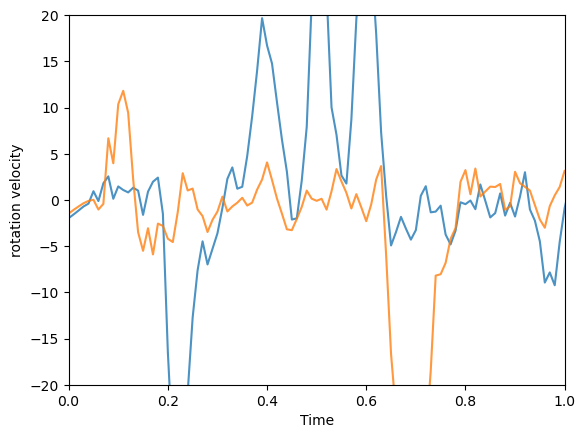

In [75]:
def wrap_to_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

theta0 = np.arctan2(orientation_fish0[:,1], orientation_fish0[:,0])
theta1 = np.arctan2(orientation_fish1[:,1], orientation_fish1[:,0])

dtheta0 = wrap_to_pi(np.diff(theta0))   # length T-1
dtheta1 = wrap_to_pi(np.diff(theta1))

omega0 = dtheta0 / dt
omega1 = dtheta1 / dt
t = np.arange(len(omega0)) * dt

plt.plot(t, omega0, label="fish 0", alpha=0.8)
plt.plot(t, omega1, label="fish 1", alpha=0.8)
plt.ylabel('rotation velocity')
plt.xlabel('Time')
plt.xlim(0, 1)
plt.ylim(-20,20)
print(np.nanmean(omega0))
print(np.nanpercentile(np.abs(omega0), 95))
print(np.nanpercentile(np.abs(omega0), 99))

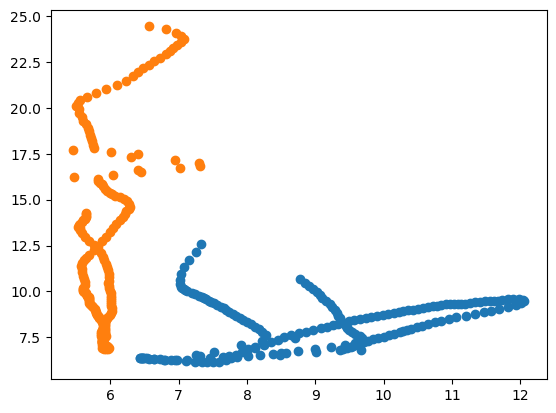

In [25]:
x0 =  pec_fish0[0:200,0]
x1 =  pec_fish1[0:200,0]
y0=  pec_fish0[0:200,1]
y1 =  pec_fish1[0:200,1]

plt.scatter(x0,y0)
plt.scatter(x1,y1)

### Relative coordinates
#### Inter fish distance

(501943, 3) (501943, 3)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


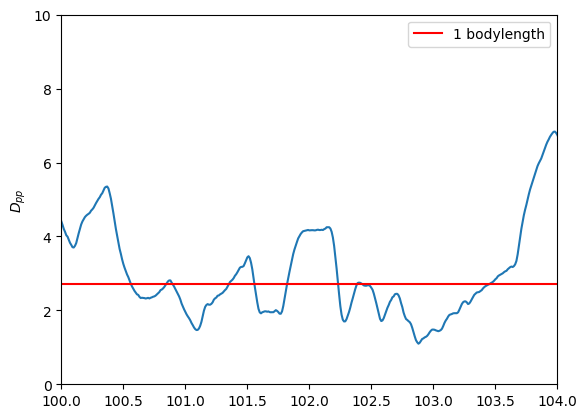

In [26]:
print(pec_fish0.shape, pec_fish1.shape)
print(type(pec_fish0), type(pec_fish1))
r = pec_fish1 - pec_fish0
d = np.linalg.norm(r, axis=1) 
t_d = np.arange(len(d))*dt
plt.plot(t_d,d)
plt.axhline(y=2.7, color='r', linestyle='-',label = '1 bodylength')
plt.xlim(100,104)
plt.ylim(0,10)
plt.ylabel(r'$D_{pp}$')
plt.legend()
plt.show()


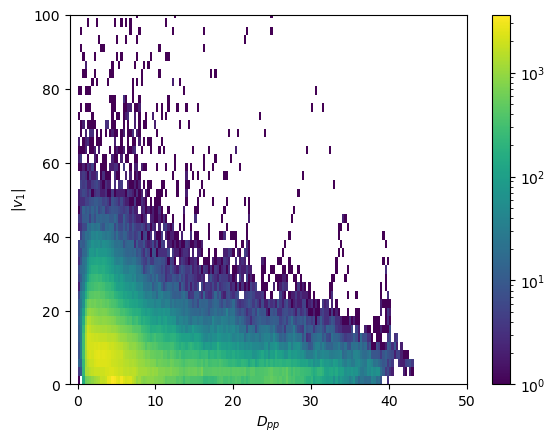

In [27]:
d=d[1:]
mask = ~np.isnan(speed_fish0) & ~np.isnan(d)

h = plt.hist2d(d[mask], speed_fish0[mask], bins=150,norm='log')
plt.colorbar(h[3])
plt.ylim(0, 100)
plt.xlim(-1,50)
plt.xlabel(r'$D_{pp}$')
plt.ylabel(r'$|v_{1}|$')

plt.show()


In [28]:
np.isnan(r).sum(), r.shape

(np.int64(24033), (501943, 3))

7.081156866523465 6.4853400910365915 4.6140958105505065


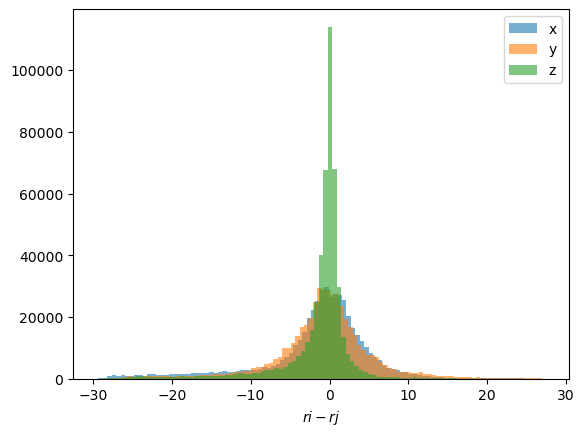

In [29]:
plt.hist(r[:,0], bins=100, alpha=0.6, label="x")
plt.hist(r[:,1], bins=100, alpha=0.6, label="y")
plt.hist(r[:,2], bins=100, alpha=0.6, label="z")
plt.xlabel(r'$ r{i} - r{j}$')
plt.legend()
print(np.nanstd(r[:,0]),np.nanstd(r[:,1]),np.nanstd(r[:,2]))

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/1519060183.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


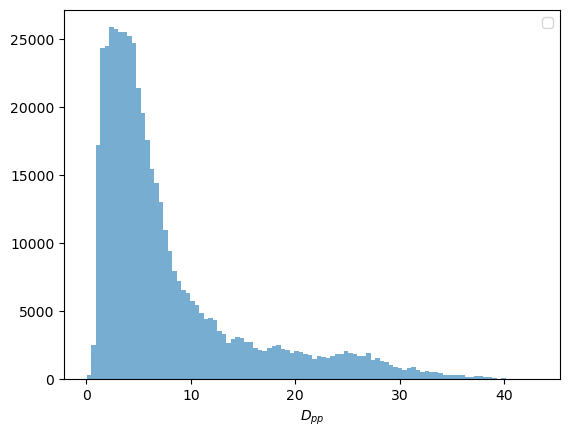

In [30]:

plt.hist(d, bins=100, alpha=0.6)
plt.xlabel(r'$D_{pp}$')
plt.legend()


In [31]:
head = X[:, :, 0, :]
pec  = X[:, :, 1, :]
tail = X[:, :, 2, :]

L_head_tail = np.nanmedian(np.linalg.norm(head - tail, axis=2))
L_head_pec  = np.nanmedian(np.linalg.norm(head - pec,  axis=2))
L_mid_tail  = np.nanmedian(np.linalg.norm(pec  - tail, axis=2))

L_head_tail, L_head_pec, L_mid_tail

(np.float64(2.7021117342564698),
 np.float64(0.791427954864457),
 np.float64(1.909397881155723))

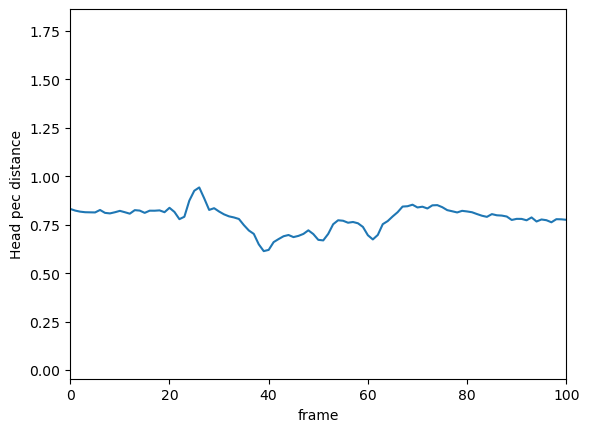

In [32]:
L1 = np.linalg.norm(vector_fish0, axis=1)
L2 = np.linalg.norm(vector_fish1, axis=1)
plt.plot(L1)
plt.xlabel("frame")
plt.ylabel("Head pec distance")
plt.xlim(0,100)
plt.show()

In [33]:
print(np.nanmean(L1))
print(np.sqrt(np.nanvar(L1)))

print(np.nanmean(L2))
print(np.sqrt(np.nanvar(L2)))

0.7936214105184474
0.06763101758422638
0.7842401921917133
0.06610493714170639


### Bearing angle


In [34]:
vector_fish0 = (head_fish0 - pec_fish0)
orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

vector_fish1 = (head_fish1 - pec_fish1)
orientation_fish1 = vector_fish1/np.linalg.norm(vector_fish1, axis=1, keepdims=True)

theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])
theta1 = np.arctan2(orientation_fish1[:, 1], orientation_fish1[:, 0])

r_01 = pec_fish1 - pec_fish0
phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
psi_01 = phi_01 - theta0
psi_01 = ((psi_01 + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

r_10 = pec_fish0 - pec_fish1
phi_10 = np.arctan2(r_10[:,1],r_10[:,0]) #dy,dx

theta1 = np.arctan2(vector_fish1[:, 1], vector_fish1[:, 0])
psi_10 = phi_10 - theta1
psi_10 = ((psi_10 + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

psi_aligned_01 = psi_01[:-1]
psi_aligned_10 = psi_10[:-1]

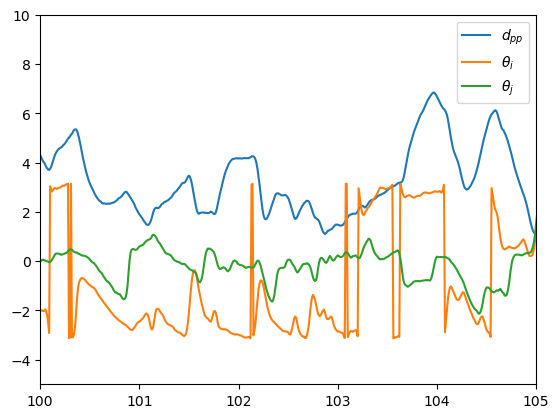

In [35]:
plt.plot(t[:-1],d, label=r'$d_{pp}$')
plt.plot(t[:-1],psi_aligned_01,label = r'$\theta_i$')
plt.plot(t[:-1],psi_aligned_10,label = r'$\theta_j$')
plt.xlim(100,105)
plt.ylim(-5,10)
plt.legend()
plt.show()

In [36]:
t = 4532

print('position i', X[t,0,1,:])
print('position j',X[t,1,1,:])
print("theta0 =", theta0[t])
print("phi_01 =", phi_01[t])
print("psi_01 =", psi_01[t])

position i [10.86545612  9.98036089  0.73747405]
position j [ 5.65498984 24.21473977  1.70032314]
theta0 = -1.630210646980079
phi_01 = 1.9216956861791223
psi_01 = -2.731278974020385


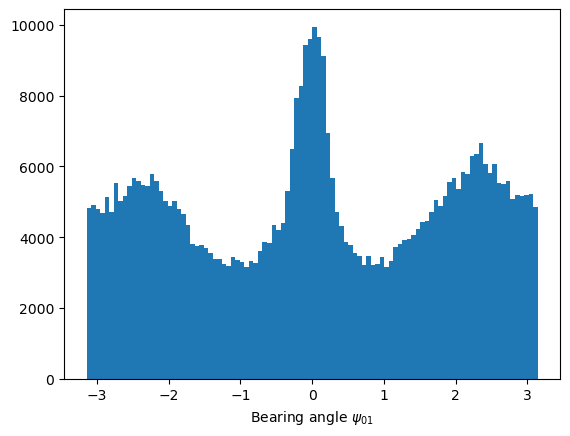

In [37]:

plt.hist(psi_01,bins = 100)
plt.xlabel(r'Bearing angle $\psi_{01}$')
plt.show()

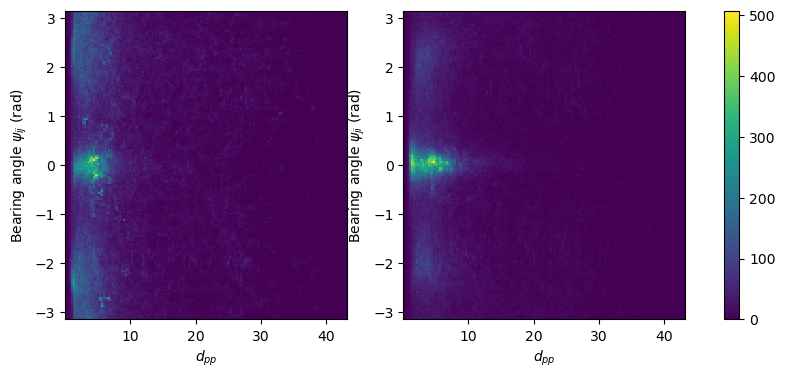

In [38]:
fig, axs = plt.subplots(1, 2,figsize=(10, 4))
mask_0 = ~np.isnan(d) & ~np.isnan(psi_01[:-1])
h0 = axs[0].hist2d(d[mask_0], psi_01[:-1][mask_0], bins=150)
axs[0].set_ylabel(r'Bearing angle $\psi_{ij}$ (rad)')
axs[0].set_xlabel(r'$d_{pp}$')


mask_1 = ~np.isnan(d) & ~np.isnan(psi_10[:-1])
h1 = axs[1].hist2d(d[mask_1], psi_10[:-1][mask_1], bins=150)
axs[1].set_xlabel(r'$d_{pp}$')
axs[1].set_ylabel(r'Bearing angle $\psi_{ji}$ (rad)')
fig.colorbar(h0[3], ax=axs)

Fish j has fish i much more often in front than behind. in chasing and face off -> would expect dominant fish to be orientated more towards the other fish - or fish j is more following then it it keeps fish i more in mind and wants it more in front of him

fish j keeps fish i in front, fish i is moving freely, fish j is reacting to fish i so maybe i is more dominant, i doesnt maintain fixed orientataion towards i

### Relative velocity

(-50.0, 50.0)

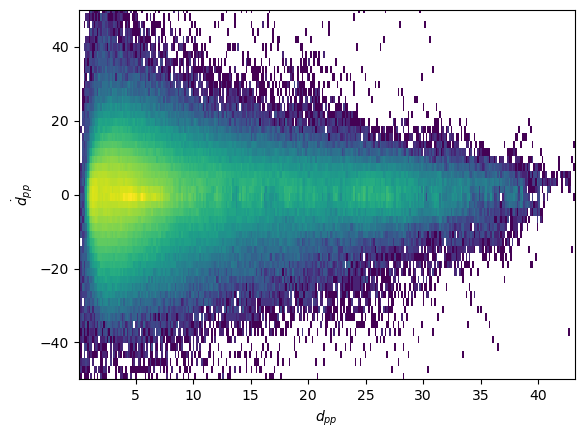

In [39]:
velocity_fish0 = (pec_fish0[1:,:] - pec_fish0[:-1,:])/dt # forward difference 
velocity_fish1 = (pec_fish1[1:,:] - pec_fish1[:-1,:])/dt
speed_fish0 = np.linalg.norm(velocity_fish0, axis=1)
speed_fish1 = np.linalg.norm(velocity_fish1, axis=1)

dv_i = velocity_fish1 -velocity_fish0

r = pec_fish1 - pec_fish0
d = np.linalg.norm(r, axis=1) 

velocity_dpp = (d[1:] - d[:-1])/dt
d = d[1:]
mask_velocity = ~np.isnan(d) & ~np.isnan(velocity_dpp)
h = plt.hist2d(d[mask_velocity],velocity_dpp[mask_velocity], bins = 300,norm='log')
plt.ylabel(r'$\dot{d}_{pp}$')
plt.xlabel(r'$d_{pp}$')
plt.ylim(-50,50)


In [40]:
r = pec_fish1 - pec_fish0
v_rel = (r[1:] - r[:-1]) / dt

r_hat = r[:-1] / np.linalg.norm(r[:-1], axis=1, keepdims=True)
v_rad = np.sum(v_rel * r_hat, axis=1)
d_aligned = d[:-1] 

In [41]:
def autocorr(x):
    x = x[np.isfinite(x)]
    x -= x.mean()
    result = np.correlate(x,x, mode='full')
    result = result[result.size // 2:]

    return result/result[0]

(501942,)
(501942,)


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/3515313232.py:30: RuntimeWarning: Mean of empty slice
  vmean_face_10.append(np.nanmean(u1_to_0[in_bin & (np.abs(psi_aligned_10) < np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/3515313232.py:28: RuntimeWarning: Mean of empty slice
  vmean_tail_01.append(np.nanmean(u0_to_1[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/3515313232.py:27: RuntimeWarning: Mean of empty slice
  vmean_side_01.append(np.nanmean(u0_to_1[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)]))


<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

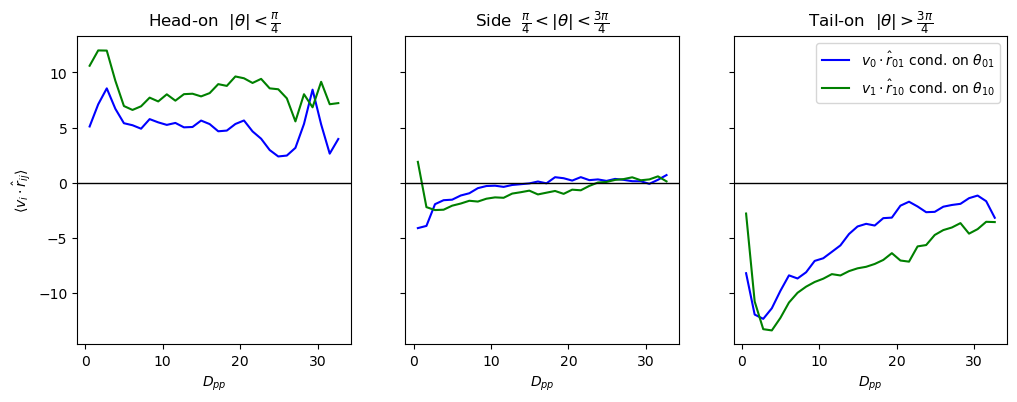

In [42]:
d_aligned = d               

r01 = pec_fish1 - pec_fish0
r10 = pec_fish0-pec_fish1

v0 = (pec_fish0[1:] - pec_fish0[:-1]) / dt
v1 = (pec_fish1[1:] - pec_fish1[:-1]) / dt

r_hat01 = r01[:-1] / np.linalg.norm(r01[:-1], axis=1, keepdims=True)
r_hat10 = -r_hat01

u0_to_1 = np.sum(v0 * r_hat01, axis=1)   # fish0 component toward fish1 direction
u1_to_0 = np.sum(v1 * r_hat10, axis=1)

bins = np.linspace(0, np.nanmax(d_aligned), 40)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

vmean_face_01, vmean_side_01, vmean_tail_01 = [], [], []
vmean_face_10, vmean_side_10, vmean_tail_10 = [], [], []

print(d_aligned.shape)
print(psi_aligned_01.shape)

for b0, b1 in zip(bins[:-1], bins[1:]):
    in_bin = (d_aligned >= b0) & (d_aligned < b1)
    vmean_face_01.append(np.nanmean(u0_to_1[in_bin & (np.abs(psi_aligned_01) < np.pi/4)]))
    vmean_side_01.append(np.nanmean(u0_to_1[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)]))
    vmean_tail_01.append(np.nanmean(u0_to_1[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)]))

    vmean_face_10.append(np.nanmean(u1_to_0[in_bin & (np.abs(psi_aligned_10) < np.pi/4)]))
    vmean_side_10.append(np.nanmean(u1_to_0[in_bin & (np.abs(psi_aligned_10) > np.pi/4) & (np.abs(psi_aligned_10) < 3*np.pi/4)]))
    vmean_tail_10.append(np.nanmean(u1_to_0[in_bin & (np.abs(psi_aligned_10) > 3*np.pi/4)]))

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers[0:30], vmean_face_01[0:30],color='b')
ax1.plot(bin_centers[0:30], vmean_face_10[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers[0:30], vmean_side_01[0:30],color='b')
ax2.plot(bin_centers[0:30], vmean_side_10[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers[0:30], vmean_tail_01[0:30],color='b',label=r'$v_0 \cdot \hat{r}_{01}$ cond. on $\theta_{01}$')
ax3.plot(bin_centers[0:30], vmean_tail_10[0:30],color = 'g',label=r'$v_1 \cdot \hat{r}_{10}$ cond. on $\theta_{10}$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$\langle v_i \cdot \hat{r}_{ij} \rangle$")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|< \frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout
# condition plot among all moments fish were at distance dpp what was average change in dpp at that moment

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/729005776.py:18: RuntimeWarning: Mean of empty slice
  vt_mean_face_10.append(np.nanmean(v_tan10[in_bin & (np.abs(psi_aligned_10) <np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/729005776.py:16: RuntimeWarning: Mean of empty slice
  vt_mean_tail_01.append(np.nanmean(v_tan01[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/729005776.py:15: RuntimeWarning: Mean of empty slice
  vt_mean_side_01.append(np.nanmean(v_tan01[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)]))


<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

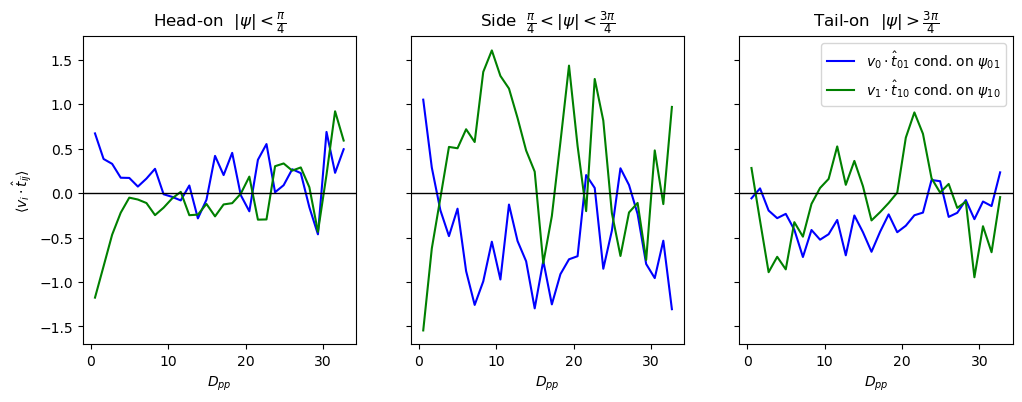

In [43]:
that01 = np.stack([-r_hat01[:,1], r_hat01[:,0]], axis=1)
that10 = -that01

v_tan01 = np.sum(v0[:, :2] * that01, axis=1)  
v_tan10 = np.sum(v1[:, :2] * that10, axis=1)  

psi_aligned_01 = psi_01[:-1]
psi_aligned_10 = psi_10[:-1]
vt_mean_face_01, vt_mean_side_01, vt_mean_tail_01 = [], [], []
vt_mean_face_10, vt_mean_side_10, vt_mean_tail_10 = [], [], []

for b0, b1 in zip(bins[:-1], bins[1:]):
    in_bin = (d_aligned >= b0) & (d_aligned < b1)
    vt_mean_face_01.append(np.nanmean(v_tan01[in_bin & (np.abs(psi_aligned_01) < np.pi/4)]))
    vt_mean_side_01.append(np.nanmean(v_tan01[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)]))
    vt_mean_tail_01.append(np.nanmean(v_tan01[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)]))

    vt_mean_face_10.append(np.nanmean(v_tan10[in_bin & (np.abs(psi_aligned_10) <np.pi/4)]))
    vt_mean_side_10.append(np.nanmean(v_tan10[in_bin & (np.abs(psi_aligned_10) > np.pi/4) & (np.abs(psi_aligned_10) < 3*np.pi/4)]))
    vt_mean_tail_10.append(np.nanmean(v_tan10[in_bin & (np.abs(psi_aligned_10) > 3*np.pi/4)]))

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers[0:30], vt_mean_face_01[0:30],color='b')
ax1.plot(bin_centers[0:30], vt_mean_face_10[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers[0:30], vt_mean_side_01[0:30],color='b')
ax2.plot(bin_centers[0:30], vt_mean_side_10[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers[0:30], vt_mean_tail_01[0:30],color='b',label=r'$ v_0 \cdot \hat{t}_{01}$ cond. on $\psi_{01}$')
ax3.plot(bin_centers[0:30], vt_mean_tail_10[0:30],color = 'g',label=r'$v_1 \cdot \hat{t}_{10}$ cond. on $\psi_{10}$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$\langle v_i \cdot \hat{t}_{ij} \rangle$")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\psi|< \frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|< \frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\psi|> \frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2454208529.py:16: RuntimeWarning: Mean of empty slice
  vt_mean_face_10.append(np.nanmean(np.abs(v_tan10[in_bin & (np.abs(psi_aligned_10) < np.pi/4)])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2454208529.py:14: RuntimeWarning: Mean of empty slice
  vt_mean_tail_01.append(np.nanmean(np.abs(v_tan01[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2454208529.py:13: RuntimeWarning: Mean of empty slice
  vt_mean_side_01.append(np.nanmean(np.abs(v_tan01[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)])))


<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

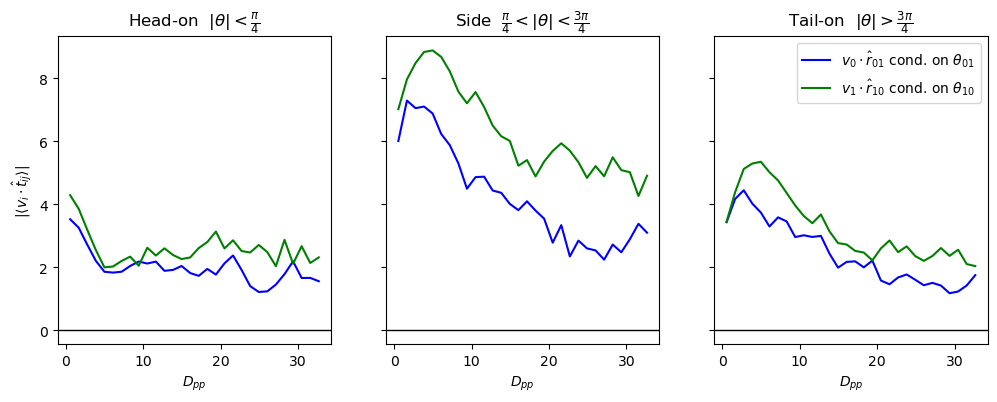

In [44]:
that01 = np.stack([-r_hat01[:,1], r_hat01[:,0]], axis=1)
that10 = -that01

v_tan01 = np.sum(v0[:, :2] * that01, axis=1)  
v_tan10 = np.sum(v1[:, :2] * that10, axis=1)  

vt_mean_face_01, vt_mean_side_01, vt_mean_tail_01 = [], [], []
vt_mean_face_10, vt_mean_side_10, vt_mean_tail_10 = [], [], []

for b0, b1 in zip(bins[:-1], bins[1:]):
    in_bin = (d_aligned >= b0) & (d_aligned < b1)
    vt_mean_face_01.append(np.nanmean(np.abs(v_tan01[in_bin & (np.abs(psi_aligned_01) < np.pi/4)])))
    vt_mean_side_01.append(np.nanmean(np.abs(v_tan01[in_bin & (np.abs(psi_aligned_01) > np.pi/4) & (np.abs(psi_aligned_01) < 3*np.pi/4)])))
    vt_mean_tail_01.append(np.nanmean(np.abs(v_tan01[in_bin & (np.abs(psi_aligned_01) > 3*np.pi/4)])))

    vt_mean_face_10.append(np.nanmean(np.abs(v_tan10[in_bin & (np.abs(psi_aligned_10) < np.pi/4)])))
    vt_mean_side_10.append(np.nanmean(np.abs(v_tan10[in_bin & (np.abs(psi_aligned_10) > np.pi/4) & (np.abs(psi_aligned_10) < 3*np.pi/4)])))
    vt_mean_tail_10.append(np.nanmean(np.abs(v_tan10[in_bin & (np.abs(psi_aligned_10) > 3*np.pi/4)])))

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers[0:30], vt_mean_face_01[0:30],color='b')
ax1.plot(bin_centers[0:30], vt_mean_face_10[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers[0:30], vt_mean_side_01[0:30],color='b')
ax2.plot(bin_centers[0:30], vt_mean_side_10[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers[0:30], vt_mean_tail_01[0:30],color='b',label=r'$v_0 \cdot \hat{r}_{01}$ cond. on $\theta_{01}$')
ax3.plot(bin_centers[0:30], vt_mean_tail_10[0:30],color = 'g',label=r'$v_1 \cdot \hat{r}_{10}$ cond. on $\theta_{10}$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{t}_{ij} \rangle|$")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|< \frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

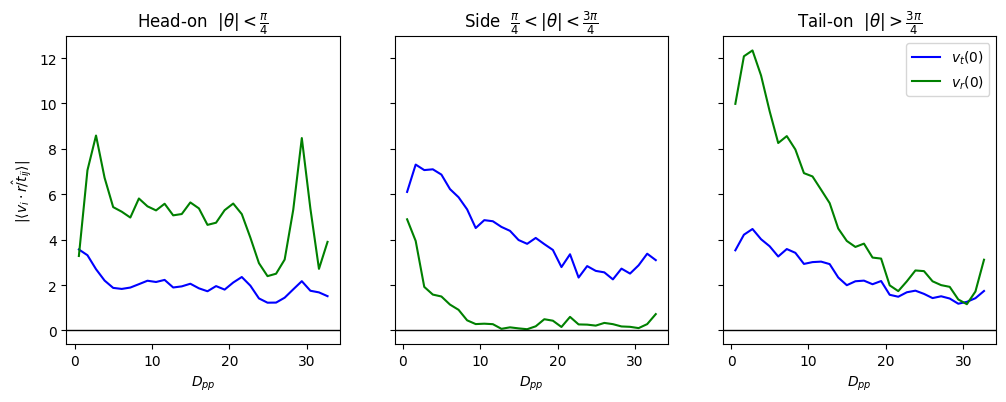

In [370]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers[0:30], vt_mean_face_01[0:30],color='b')
ax1.plot(bin_centers[0:30], np.abs(vmean_face_01)[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers[0:30], vt_mean_side_01[0:30],color='b')
ax2.plot(bin_centers[0:30], np.abs(vmean_side_01)[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers[0:30], vt_mean_tail_01[0:30],color='b',label=r'$v_{t} (0)$')
ax3.plot(bin_centers[0:30], np.abs(vmean_tail_01)[0:30],color = 'g',label=r'$v_{r} (0)$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{r/t}_{ij} \rangle$|")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|< \frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|<\frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

In [45]:
print("abs(v_tan) range:", np.nanmin(vt_mean_face_01), np.nanmax(vt_mean_face_01))
print("abs(u_rad) range:", np.nanmin(np.abs(vmean_face_01)), np.nanmax(np.abs(vmean_face_01)))

abs(v_tan) range: 1.22034491952113 3.7105447854065146
abs(u_rad) range: 2.3850737455258297 8.557607244180765


<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

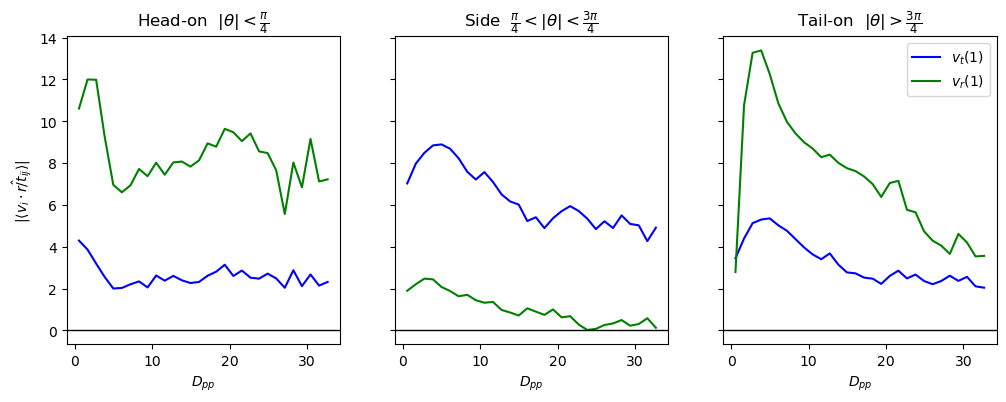

In [46]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers[0:30], vt_mean_face_10[0:30],color='b')
ax1.plot(bin_centers[0:30], np.abs(vmean_face_10)[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers[0:30], vt_mean_side_10[0:30],color='b')
ax2.plot(bin_centers[0:30], np.abs(vmean_side_10)[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers[0:30], vt_mean_tail_10[0:30],color='b',label=r'$v_{t} (1)$')
ax3.plot(bin_centers[0:30], np.abs(vmean_tail_10)[0:30],color = 'g',label=r'$v_{r} (1)$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{r/t}_{ij} \rangle$|")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|<\frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

In [277]:
tangential_velocity  = autocorr(v_tan01)
radial_veloctiy = autocorr(u0_to_1)

In [287]:
def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi
dtheta = wrap_pi(theta1 - theta0)
omega_auto = autocorr(dtheta)

In [293]:
acf_cos_t = autocorr(np.cos(dtheta))
acf_sin_t = autocorr(np.sin(dtheta))
acf_theta = 0.5*(acf_cos_t + acf_sin_t)

acf_cos_p = autocorr(np.cos(psi_01))
acf_sin_p = autocorr(np.sin(psi_01))
acf_psi= 0.5*(acf_cos_p + acf_sin_p)

In [495]:
heading = orientation_fish0
heading = heading / np.linalg.norm(heading, axis=1, keepdims=True)

u_parallel = np.sum(velocity_fish0 * heading[:-1], axis=1)
u_auto = autocorr(u_parallel)

In [580]:
v_tan_fromu = u_parallel*np.sin(psi_aligned_01)
v_par_fromu = u_parallel*np.cos(psi_aligned_01)


In [581]:
v_tan_fromu_auto = autocorr(v_tan_fromu)
v_par_fromu_auto = autocorr(v_par_fromu)


In [597]:
import numpy as np
from scipy.signal import savgol_filter

def smooth_angle(theta, window=21, poly=3):
    # smooth on unit circle
    c = np.cos(theta)
    s = np.sin(theta)
    c_s = savgol_filter(c, window_length=window, polyorder=poly, mode="interp")
    s_s = savgol_filter(s, window_length=window, polyorder=poly, mode="interp")
    return np.arctan2(s_s, c_s)

theta0 = np.arctan2(orientation_fish0[:,1], orientation_fish0[:,0])
theta1 = np.arctan2(orientation_fish1[:,1], orientation_fish1[:,0])

theta0_s = smooth_angle(theta0, window=21, poly=3)
theta1_s = smooth_angle(theta1, window=21, poly=3)

# central difference omega (smoother + time-centered)
def wrap_to_pi(a): 
    return (a + np.pi) % (2*np.pi) - np.pi

omega0 = wrap_to_pi(theta0_s[2:] - theta0_s[:-2]) / (2*dt)
omega1 = wrap_to_pi(theta1_s[2:] - theta1_s[:-2]) / (2*dt)

In [598]:
omega_auto_new = autocorr(omega0)

In [584]:
auto_cospsi = autocorr(np.cos(psi_aligned_01))

(0.0, 500.0)

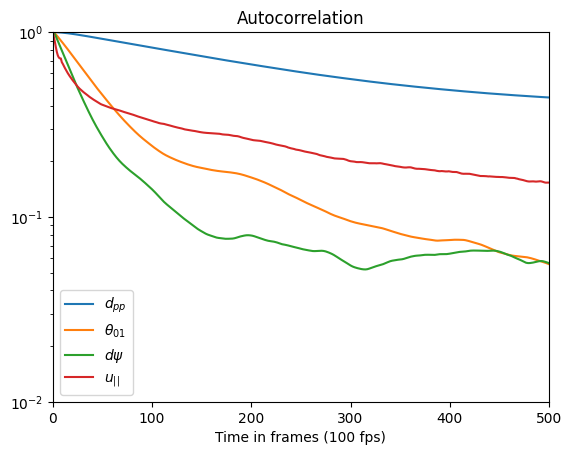

In [663]:
#plt.plot(speed0_auto, label = 'Speed fish 0')
#plt.plot(speed1_auto, label = 'Speed fish 1')
plt.plot(distance_auto, label = r'$d_{pp}$')
plt.plot(acf_psi,label=r'$\theta_{01}$')
plt.plot(acf_theta,label=r'$ d\psi$')
plt.plot(u_auto,label=r'$u_{||}$')
#plt.plot(auto_cospsi,label='cos')
#plt.plot(theta_auto0, label = 'theta_auto0')
#plt.plot(theta_auto1, label = 'theta_auto1')
#plt.plot(bearing1, label = 'bearing1')
#plt.plot(rotational_velocity0, label = 'rotational velocity 0')
#plt.plot(rotational_velocity1, label = 'rotational velocity 1')
#plt.plot(velocity_dpp_auto,label = 'velocity radial')
#plt.plot(v_tan_fromu_auto,label='v_tan')
#plt.plot(v_par_fromu_auto,label='v_par')
#plt.plot(omega_auto_new,label= r'$\omega$')
#plt.plot(tangential_velocity,label = 'tangential velocity')
#plt.plot(radial_veloctiy,label = 'radial velocity')

plt.legend()
plt.title('Autocorrelation')
plt.xlabel('Time in frames (100 fps)')
plt.yscale('log')
plt.ylim(10**-2,1)
plt.xlim(0,500)

In [612]:
print(v_par_fromu.shape, u0_to_1.shape)
v_par_fromu_f= v_par_fromu[31500:175400]
u0_to_1_f = u0_to_1[31500:175400]
mask = np.isfinite(v_par_fromu_f) & np.isfinite(u0_to_1_f)
r = np.corrcoef(v_par_fromu_f[mask], u0_to_1_f[mask])[0,1]
print("corr(v_par_fromu, radial_velocity) =", r)

(501942,) (501942,)
corr(v_par_fromu, radial_velocity) = 0.963645914641663


In [614]:
v_tan_fromu_f = v_tan_fromu[31500:175400]
v_tan01_f = v_tan01[31500:175400]
mask = np.isfinite(v_tan_fromu_f) & np.isfinite(v_tan01_f)

r = np.corrcoef(v_tan_fromu_f[mask], v_tan01_f[mask])[0,1]
print("corr(v_par_fromu, radial_velocity) =", r)

np.corrcoef(-v_tan_fromu_f[mask], v_tan01_f[mask])[0,1]

corr(v_par_fromu, radial_velocity) = -0.9184499003705473


0.9184499003705473

### With filter on fightbout 

In [48]:
with h5py.File("/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/fightBouts.h5", "r") as j:
    fb = j["fight_bout_info"][:]

print(fb)

[[     0 643500 805400 161900]
 [     1 493700 655400 161700]
 [     2  31500 175400 143900]
 [     3 331300 436400 105100]
 [     5 448500 559400 110900]
 [     7 505500 553400  47900]
 [     8 181500 256200  74700]
 [     8 274700 334400  59700]
 [    10  19700  79400  59700]
 [    11 214900 280400  65500]
 [    12 142500 226400  83900]
 [    12 262500 343400  80900]
 [    13 694500 745600  51100]
 [    14   7700  61800  54100]
 [    15  13500 184400 170900]
 [    18 388700 556400 167700]
 [    19 526700 571200  44500]
 [    20  40900 169600 128700]]


In [3]:
def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]

    return expIdx, fightbouts
EXP_id , fightbout = get_experimentID_fightbouts( "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5")

print(fightbout)


[[     2  31500 175400 143900]]


In [4]:
start = fightbout[0,1]
stop  = fightbout[0,2]
duration = fightbout[0, 3]


In [6]:
path = "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
f = h5py.File(path, "r")

In [7]:
Y = f["tracks_3D_smooth"]
pec_f = Y[start:stop, :, 1, :]
pec_fish0_f = pec_f[:, 0, :]
pec_fish1_f = pec_f[:, 1, :]

dt = 1/100

velocity_fish0_f = (pec_fish0_f[1:] - pec_fish0_f[:-1]) / dt
velocity_fish1_f = (pec_fish1_f[1:] - pec_fish1_f[:-1]) / dt

speed_fish0_f = np.linalg.norm(velocity_fish0_f, axis=1)
speed_fish1_f = np.linalg.norm(velocity_fish1_f, axis=1)

r_f = pec_fish1_f - pec_fish0_f
d_f = np.linalg.norm(r_f, axis=1) 

In [8]:
head_fish0_f = X[start:stop, 0, 0, :]
head_fish1_f = X[start:stop, 1, 0, :]

vector_fish0_f = (head_fish0_f - pec_fish0_f)
orientation_fish0_f = vector_fish0_f/np.linalg.norm(vector_fish0_f, axis=1, keepdims=True)

vector_fish1_f = (head_fish1_f - pec_fish1_f)
orientation_fish1_f = vector_fish1_f/np.linalg.norm(vector_fish1_f, axis=1, keepdims=True)

heading0_f = orientation_fish0_f
heading0_f = heading0_f / np.linalg.norm(heading0_f, axis=1, keepdims=True)

speed0_f = np.linalg.norm(velocity_fish0_f, axis=1)
dot_f = np.sum(velocity_fish0_f * heading0_f[:-1], axis=1)  # align lengths if needed
cos_phi_f = dot_f / (speed0_f + 1e-8)

phi_f = np.arccos(np.clip(cos_phi_f, -1, 1))
print(np.nanmedian(phi_f)*(180/np.pi))

plt.hist(phi_f*(180/np.pi),bins = 200)
plt.xlabel('angle in degrees')


NameError: name 'X' is not defined

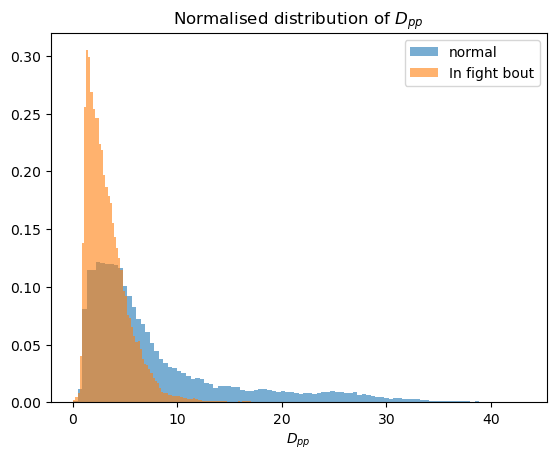

In [56]:

plt.hist(d, bins=100, alpha=0.6,label ='normal',density = True)
plt.hist(d_f,bins=100,alpha = 0.6,label= 'In fight bout',density = True)
plt.xlabel(r'$D_{pp}$')
plt.title(r'Normalised distribution of $D_{pp}$')
plt.legend()


In [57]:
head_fish0_f = Y[start:stop, 0, 0, :]
head_fish1_f = Y[start:stop, 1, 0, :]

vector_fish0_f = (head_fish0_f - pec_fish0_f)
orientation_fish0_f= vector_fish0_f/np.linalg.norm(vector_fish0_f, axis=1, keepdims=True)

vector_fish1_f = (head_fish1_f - pec_fish1_f)
orientation_fish1_f = vector_fish1_f/np.linalg.norm(vector_fish1_f, axis=1, keepdims=True)

theta0_f = np.arctan2(orientation_fish0_f[:, 1],  orientation_fish0_f[:, 0])
theta1_f = np.arctan2(orientation_fish1_f[:, 1], orientation_fish1_f[:, 0])

r_01_f = pec_fish1_f - pec_fish0_f
phi_01_f = np.arctan2(r_01_f[:,1],r_01_f[:,0]) #dy,dx

psi_01_f = phi_01_f - theta0_f
psi_01_f = ((psi_01_f + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

r_10_f= pec_fish0_f - pec_fish1_f
phi_10_f = np.arctan2(r_10_f[:,1],r_10_f[:,0]) #dy,dx

psi_10_f = phi_10_f - theta1_f
psi_10_f = ((psi_10_f + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

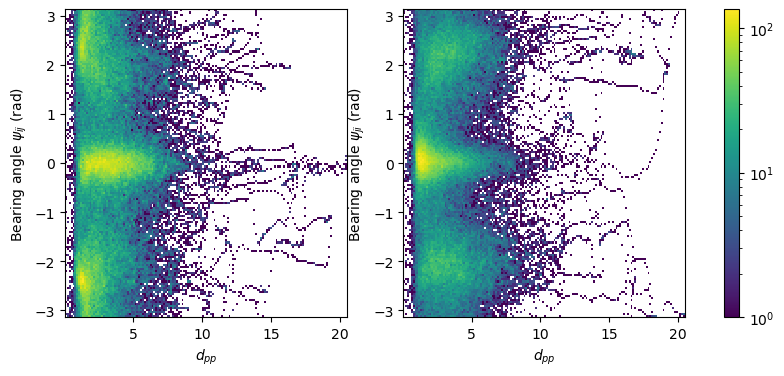

In [58]:
fig, axs = plt.subplots(1, 2,figsize=(10, 4))
d_aligned_f = d_f[:-1]
mask_0 = ~np.isnan(d_aligned_f) & ~np.isnan(psi_01_f[:-1])
h0 = axs[0].hist2d(d_aligned_f[mask_0], psi_01_f[:-1][mask_0], bins=150, norm ='log')
axs[0].set_ylabel(r'Bearing angle $\psi_{ij}$ (rad)')
axs[0].set_xlabel(r'$d_{pp}$')


mask_1 = ~np.isnan(d_aligned_f) & ~np.isnan(psi_10_f[:-1])
h1 = axs[1].hist2d(d_aligned_f[mask_1], psi_10_f[:-1][mask_1], bins=150,norm ='log')
axs[1].set_xlabel(r'$d_{pp}$')
axs[1].set_ylabel(r'Bearing angle $\psi_{ji}$ (rad)')
fig.colorbar(h0[3], ax=axs)

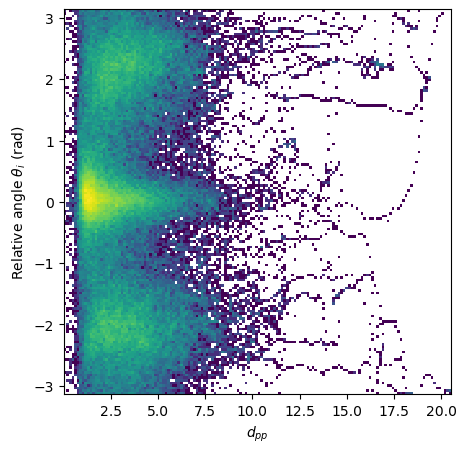

In [59]:
plt.subplots(figsize=(5, 5))
mask_1 = ~np.isnan(d_aligned_f) & ~np.isnan(psi_10_f[:-1])
h1 = plt.hist2d( d_aligned_f[mask_1], psi_10_f[:-1][mask_1],bins=150,norm ='log')
plt.xlabel(r'$d_{pp}$')
plt.ylabel(r'Relative angle $\theta_{i}$ (rad)')
plt.colorbar(h1[3], ax=axs)

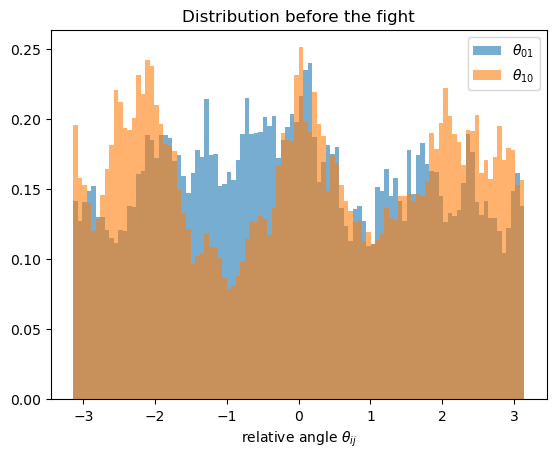

In [60]:

plt.hist(psi_01[0:start],bins = 100,alpha = 0.6,label =r'$\theta_{01}$',density = True)
plt.hist(psi_10[0:start],bins = 100,alpha = 0.6,label= r'$\theta_{10}$',density = True)
plt.xlabel(r'relative angle $\theta_{ij}$')
plt.legend()
plt.title('Distribution before the fight')
plt.show()

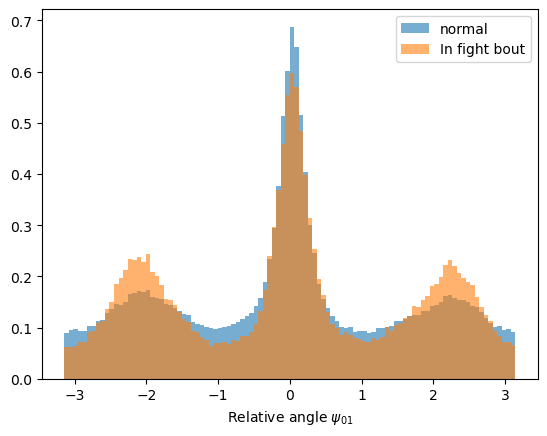

In [61]:

plt.hist(psi_10,bins = 100,alpha = 0.6,label ='normal',density = True)
plt.hist(psi_10_f,bins = 100,alpha = 0.6,label= 'In fight bout',density = True)
plt.xlabel(r'Relative angle $\psi_{01}$')
plt.legend()
plt.show()

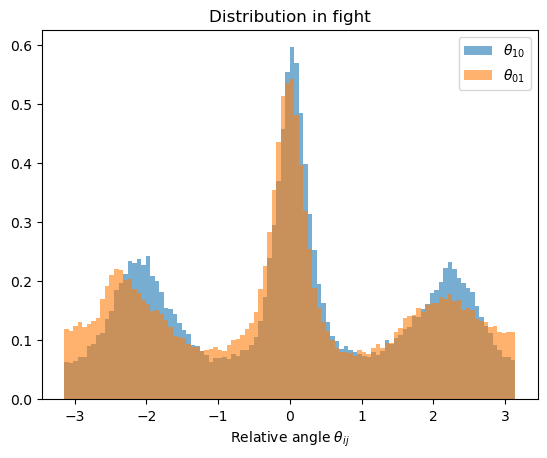

In [62]:
plt.hist(psi_10_f,bins = 100,alpha = 0.6,label= r'$\theta_{10}$',density = True)
plt.hist(psi_01_f,bins = 100,alpha = 0.6,label= r'$\theta_{01}$',density = True)
plt.xlabel(r'Relative angle $\theta_{ij}$')
plt.legend()
plt.title('Distribution in fight')
plt.show()


In [64]:
Y = f["tracks_3D_smooth"]
head_fish0_after= Y[stop:, 0, 0, :]
head_fish1_after = Y[stop:, 1, 0, :]

pec_after = Y[stop:, :, 1, :]
pec_fish0_after = pec_after[:, 0, :]
pec_fish1_after = pec_after[:, 1, :]

vector_fish0_after = (head_fish0_after - pec_fish0_after)
orientation_fish0_after= vector_fish0_after/np.linalg.norm(vector_fish0_after, axis=1, keepdims=True)

vector_fish1_after = (head_fish1_after - pec_fish1_after)
orientation_fish1_after= vector_fish1_after/np.linalg.norm(vector_fish1_after, axis=1, keepdims=True)

theta0_after = np.arctan2(orientation_fish0_after[:, 1],  orientation_fish0_after[:, 0])
theta1_after = np.arctan2(orientation_fish1_after[:, 1], orientation_fish1_after[:, 0])

r_01_after = pec_fish1_after - pec_fish0_after
phi_01_after = np.arctan2(r_01_after[:,1],r_01_after[:,0]) #dy,dx

psi_01_after= phi_01_after - theta0_after
psi_01_after= ((psi_01_after + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

r_10_after= pec_fish0_after - pec_fish1_after
phi_10_after = np.arctan2(r_10_after[:,1],r_10_after[:,0]) #dy,dx

psi_10_after = phi_10_after - theta1_after
psi_10_after= ((psi_10_after + np.pi) % (2*np.pi) - np.pi) # wrap interval from -pi to pi

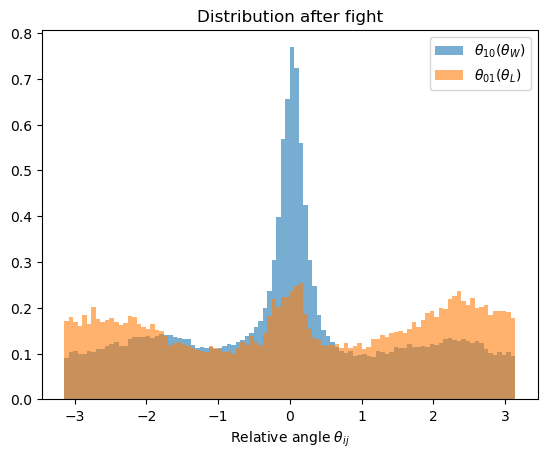

In [65]:
plt.hist(psi_10_after,bins = 100,alpha = 0.6,label= r'$\theta_{10} (\theta_{W})$',density = True)
plt.hist(psi_01_after,bins = 100,alpha = 0.6,label= r'$\theta_{01} (\theta_{L})$',density = True)
plt.xlabel(r'Relative angle $\theta_{ij}$')
plt.title('Distribution after fight')
plt.legend()
plt.show()

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/717002740.py:28: RuntimeWarning: Mean of empty slice
  vmean_tail_01_f.append(np.nanmean(u0_to_1_f[in_bin & (np.abs(psi_aligned_01_f) > 3*np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/717002740.py:30: RuntimeWarning: Mean of empty slice
  vmean_face_10_f.append(np.nanmean(u1_to_0_f[in_bin & (np.abs(psi_aligned_10_f) < np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/717002740.py:27: RuntimeWarning: Mean of empty slice
  vmean_side_01_f.append(np.nanmean(u0_to_1_f[in_bin & (np.abs(psi_aligned_01_f) > np.pi/4) & (np.abs(psi_aligned_01_f) < 3*np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/717002740.py:31: RuntimeWarning: Mean of empty slice
  vmean_side_10_f.append(np.nanmean(u1_to_0_f[in_bin & (np.abs(psi_aligned_10_f) > np.pi/4) & (np.abs(psi_aligned_10_f) < 3*np.pi/4)]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176

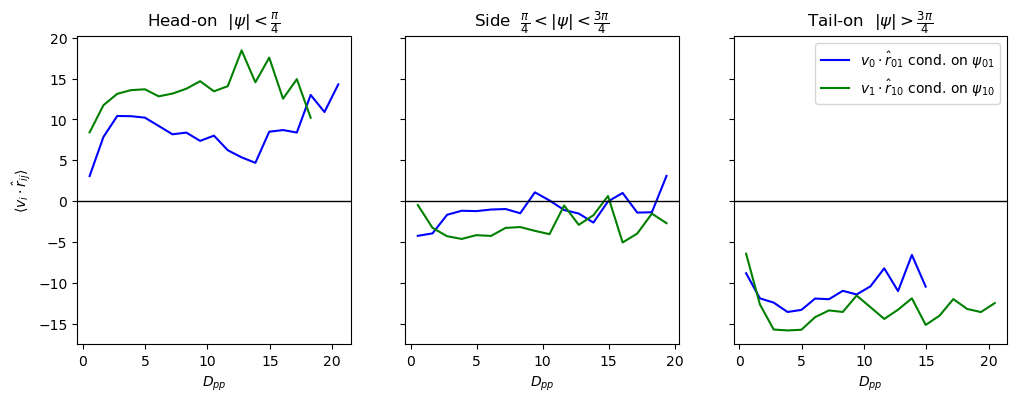

In [66]:

r01_f = pec_fish1_f - pec_fish0_f
r10_f = pec_fish0_f-pec_fish1_f

d_f = np.linalg.norm(r01_f[:, :2], axis=1)        # or axis=1 for full 3D distance
d_aligned_f = d_f[:-1] 

v0_f = (pec_fish0_f[1:] - pec_fish0_f[:-1]) / dt
v1_f = (pec_fish1_f[1:] - pec_fish1_f[:-1]) / dt

r_hat01_f = r01_f[:-1] / np.linalg.norm(r01_f[:-1], axis=1, keepdims=True)
r_hat10_f = -r_hat01_f

u0_to_1_f = np.sum(v0_f * r_hat01_f, axis=1)   # fish0 component toward fish1 direction
u1_to_0_f = np.sum(v1_f * r_hat10_f, axis=1)

bins_f = np.linspace(0, np.nanmax(d_aligned), 40)
bin_centers_f = 0.5 * (bins[1:] + bins[:-1])

psi_aligned_01_f = psi_01_f[:-1]
psi_aligned_10_f = psi_10_f[:-1]
vmean_face_01_f, vmean_side_01_f, vmean_tail_01_f = [], [], []
vmean_face_10_f, vmean_side_10_f, vmean_tail_10_f = [], [], []

for b0, b1 in zip(bins_f[:-1], bins_f[1:]):
    in_bin = (d_aligned_f >= b0) & (d_aligned_f < b1)
    vmean_face_01_f.append(np.nanmean(u0_to_1_f[in_bin & (np.abs(psi_aligned_01_f) < np.pi/4)]))
    vmean_side_01_f.append(np.nanmean(u0_to_1_f[in_bin & (np.abs(psi_aligned_01_f) > np.pi/4) & (np.abs(psi_aligned_01_f) < 3*np.pi/4)]))
    vmean_tail_01_f.append(np.nanmean(u0_to_1_f[in_bin & (np.abs(psi_aligned_01_f) > 3*np.pi/4)]))

    vmean_face_10_f.append(np.nanmean(u1_to_0_f[in_bin & (np.abs(psi_aligned_10_f) < np.pi/4)]))
    vmean_side_10_f.append(np.nanmean(u1_to_0_f[in_bin & (np.abs(psi_aligned_10_f) > np.pi/4) & (np.abs(psi_aligned_10_f) < 3*np.pi/4)]))
    vmean_tail_10_f.append(np.nanmean(u1_to_0_f[in_bin & (np.abs(psi_aligned_10_f) > 3*np.pi/4)]))

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers, vmean_face_01_f,color='b')
ax1.plot(bin_centers, vmean_face_10_f,color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers, vmean_side_01_f,color='b')
ax2.plot(bin_centers, vmean_side_10_f,color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers, vmean_tail_01_f,color='b',label=r'$v_0 \cdot \hat{r}_{01}$ cond. on $\psi_{01}$')
ax3.plot(bin_centers, vmean_tail_10_f,color = 'g',label=r'$v_1 \cdot \hat{r}_{10}$ cond. on $\psi_{10}$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$\langle v_i \cdot \hat{r}_{ij} \rangle$")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\psi|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|< \frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\psi|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout
fig.show()
# condition plot among all moments fish were at distance dpp what was average change in dpp at that moment

/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/860962390.py:16: RuntimeWarning: Mean of empty slice
  vt_mean_tail_01_f.append(np.nanmean(np.abs(v_tan01_f[in_bin & (np.abs(psi_aligned_01_f) > 3*np.pi/4)])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/860962390.py:18: RuntimeWarning: Mean of empty slice
  vt_mean_face_10_f.append(np.nanmean(np.abs(v_tan10_f[in_bin & (np.abs(psi_aligned_10_f) < np.pi/4)])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/860962390.py:15: RuntimeWarning: Mean of empty slice
  vt_mean_side_01_f.append(np.nanmean(np.abs(v_tan01_f[in_bin & (np.abs(psi_aligned_01_f) > np.pi/4) & (np.abs(psi_aligned_01_f) < 3*np.pi/4)])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/860962390.py:19: RuntimeWarning: Mean of empty slice
  vt_mean_side_10_f.append(np.nanmean(np.abs(v_tan10_f[in_bin & (np.abs(psi_aligned_10_f) > np.pi/4) & (np.abs(psi_aligned_10_f) < 3*np.pi/4)])))
/var/folders/3v/6kq_73ns

<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

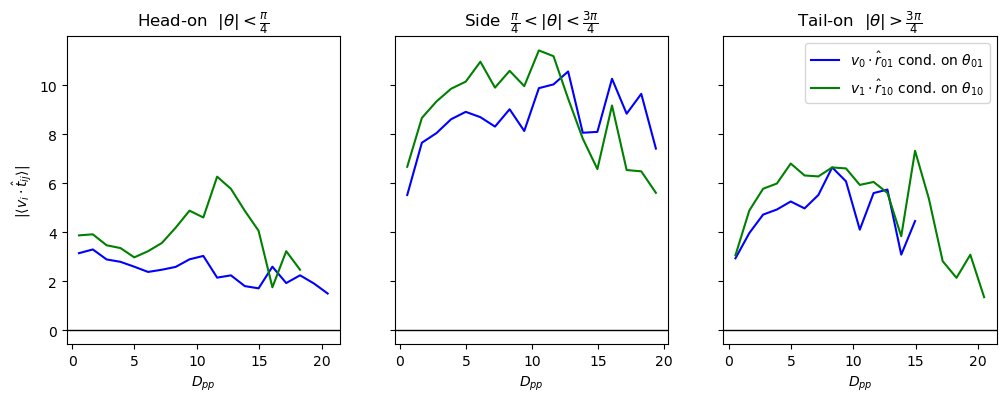

In [67]:
that01_f = np.stack([-r_hat01_f[:,1], r_hat01_f[:,0]], axis=1)
that10_f = -that01_f

v_tan01_f = np.sum(v0_f[:, :2] * that01_f, axis=1)  
v_tan10_f = np.sum(v1_f[:, :2] * that10_f, axis=1)  

psi_aligned_01_f = psi_01_f[:-1]
psi_aligned_10_f = psi_10_f[:-1]
vt_mean_face_01_f, vt_mean_side_01_f, vt_mean_tail_01_f = [], [], []
vt_mean_face_10_f, vt_mean_side_10_f, vt_mean_tail_10_f = [], [], []

for b0, b1 in zip(bins_f[:-1], bins_f[1:]):
    in_bin = (d_aligned_f >= b0) & (d_aligned_f < b1)
    vt_mean_face_01_f.append(np.nanmean(np.abs(v_tan01_f[in_bin & (np.abs(psi_aligned_01_f) < np.pi/4)])))
    vt_mean_side_01_f.append(np.nanmean(np.abs(v_tan01_f[in_bin & (np.abs(psi_aligned_01_f) > np.pi/4) & (np.abs(psi_aligned_01_f) < 3*np.pi/4)])))
    vt_mean_tail_01_f.append(np.nanmean(np.abs(v_tan01_f[in_bin & (np.abs(psi_aligned_01_f) > 3*np.pi/4)])))

    vt_mean_face_10_f.append(np.nanmean(np.abs(v_tan10_f[in_bin & (np.abs(psi_aligned_10_f) < np.pi/4)])))
    vt_mean_side_10_f.append(np.nanmean(np.abs(v_tan10_f[in_bin & (np.abs(psi_aligned_10_f) > np.pi/4) & (np.abs(psi_aligned_10_f) < 3*np.pi/4)])))
    vt_mean_tail_10_f.append(np.nanmean(np.abs(v_tan10_f[in_bin & (np.abs(psi_aligned_10_f) > 3*np.pi/4)])))

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers_f[0:30], vt_mean_face_01_f[0:30],color='b')
ax1.plot(bin_centers_f[0:30], vt_mean_face_10_f[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers_f[0:30], vt_mean_side_01_f[0:30],color='b')
ax2.plot(bin_centers_f[0:30], vt_mean_side_10_f[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers_f[0:30], vt_mean_tail_01_f[0:30],color='b',label=r'$v_0 \cdot \hat{r}_{01}$ cond. on $\theta_{01}$')
ax3.plot(bin_centers_f[0:30], vt_mean_tail_10_f[0:30],color = 'g',label=r'$v_1 \cdot \hat{r}_{10}$ cond. on $\theta_{10}$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{t}_{ij} \rangle|$")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|< \frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

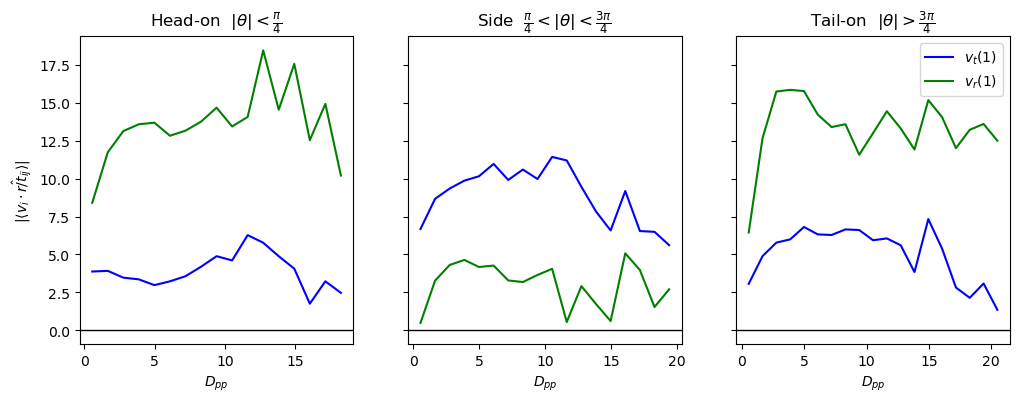

In [68]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers_f[0:30], vt_mean_face_10_f[0:30],color='b')
ax1.plot(bin_centers_f[0:30], np.abs(vmean_face_10_f)[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers_f[0:30], vt_mean_side_10_f[0:30],color='b')
ax2.plot(bin_centers_f[0:30], np.abs(vmean_side_10_f)[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers_f[0:30], vt_mean_tail_10_f[0:30],color='b',label=r'$v_{t} (1)$')
ax3.plot(bin_centers_f[0:30], np.abs(vmean_tail_10_f)[0:30],color = 'g',label=r'$v_{r} (1)$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{r/t}_{ij} \rangle$|")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|<\frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|<\frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

<bound method Figure.tight_layout of <Figure size 1200x400 with 3 Axes>>

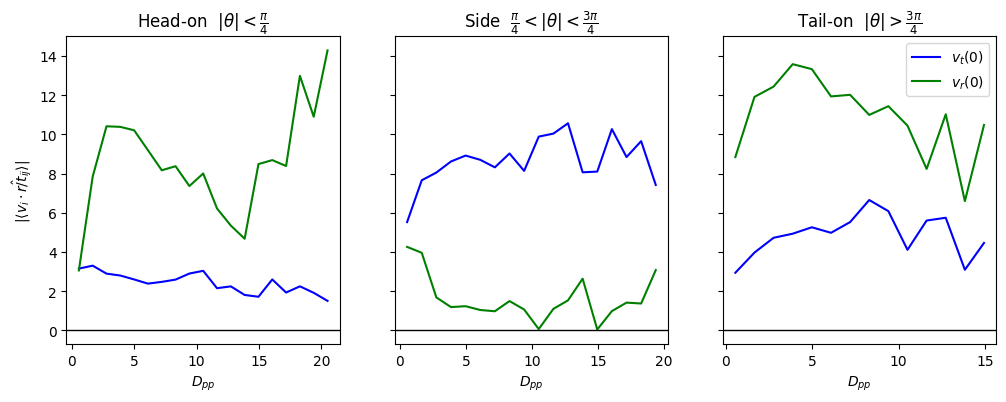

In [379]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, sharey = True, figsize = (12,4))

ax1.plot(bin_centers_f[0:30], vt_mean_face_01_f[0:30],color='b')
ax1.plot(bin_centers_f[0:30], np.abs(vmean_face_01_f)[0:30],color = 'g')
ax1.axhline(0, color='k', lw=1)

ax2.plot(bin_centers_f[0:30], vt_mean_side_01_f[0:30],color='b')
ax2.plot(bin_centers_f[0:30], np.abs(vmean_side_01_f)[0:30],color = 'g')
ax2.axhline(0, color='k', lw=1)

ax3.plot(bin_centers_f[0:30], vt_mean_tail_01_f[0:30],color='b',label=r'$v_{t} (0)$')
ax3.plot(bin_centers_f[0:30], np.abs(vmean_tail_01_f)[0:30],color = 'g',label=r'$v_{r} (0)$')
ax3.axhline(0, color='k', lw=1)

ax1.set_ylabel(r"$|\langle v_i \cdot \hat{r/t}_{ij} \rangle$|")
ax1.set_xlabel(r"$D_{pp}$")
ax2.set_xlabel(r"$D_{pp}$")
ax3.set_xlabel(r"$D_{pp}$")
ax1.set_title(r"Head-on  $|\theta|< \frac{\pi}{4}$")
ax2.set_title(r"Side  $\frac{\pi}{4}<|\theta|<\frac{3 \pi}{4}$")
ax3.set_title(r"Tail-on  $|\theta|>\frac{3 \pi}{4}$")
ax3.legend()
fig.tight_layout

### Acceleration


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2620307681.py:36: RuntimeWarning: Mean of empty slice
  arad_face_10_f.append(np.nanmean(np.abs(a_rad10_f[face])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2620307681.py:40: RuntimeWarning: Mean of empty slice
  atan_face_10_f.append(np.nanmean(np.abs(a_tan10_f[face])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2620307681.py:37: RuntimeWarning: Mean of empty slice
  arad_side_10_f.append(np.nanmean(np.abs(a_rad10_f[side])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_41176/2620307681.py:41: RuntimeWarning: Mean of empty slice
  atan_side_10_f.append(np.nanmean(np.abs(a_tan10_f[side])))


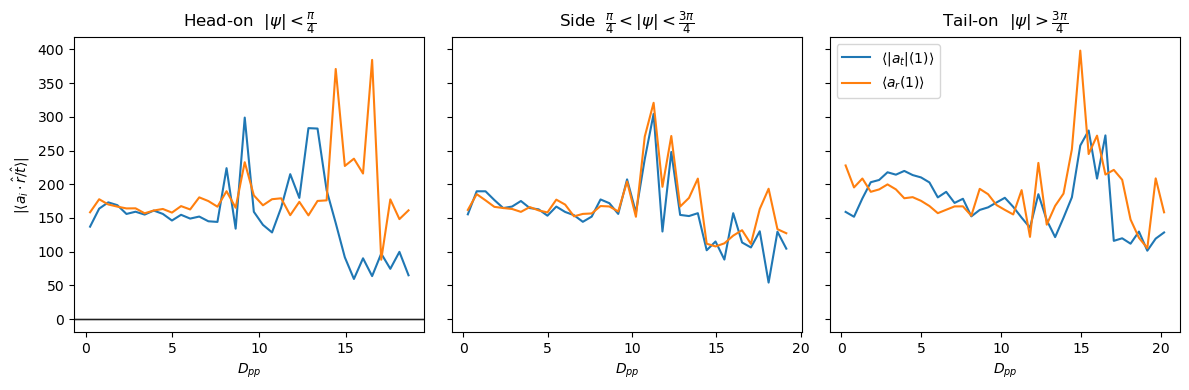

In [69]:

a0_f = (pec_fish0_f[2:] - 2*pec_fish0_f[1:-1] + pec_fish0_f[:-2]) / dt**2
a1_f = (pec_fish1_f[2:] - 2*pec_fish1_f[1:-1] + pec_fish1_f[:-2]) / dt**2

r01_mid_f = pec_fish1_f[1:-1] - pec_fish0_f[1:-1] 
r01_xy = r01_mid_f[:, :2]
d_mid_f = np.linalg.norm(r01_mid_f[:, :2], axis=1)

r_hat01_f = r01_xy / np.linalg.norm(r01_xy, axis=1, keepdims=True)  
r_hat10_f = -r_hat01_f

t_hat01_f = np.stack([-r_hat01_f[:,1], r_hat01_f[:,0]], axis=1)
t_hat10_f = -t_hat01_f

a_rad01_f = np.sum(a0_f[:, :2] * r_hat01_f, axis=1)         
a_rad10_f = np.sum(a1_f[:, :2] * r_hat10_f, axis=1)   
a_tan01_f = np.sum(a0_f[:, :2] * t_hat01_f, axis=1)  
a_tan10_f = np.sum(a1_f[:, :2] * t_hat10_f, axis=1)

psi_01_mid_f = psi_01_f[1:-1]
psi_10_mid_f = psi_10_f[1:-1]


bins_a_f = np.linspace(0, np.nanmax(d_mid_f), 40)
bin_centers_a_f = 0.5 * (bins_a_f[1:] + bins_a_f[:-1])

arad_face_10_f, arad_side_10_f, arad_tail_10_f = [], [], []
atan_face_10_f, atan_side_10_f, atan_tail_10_f = [], [], []

for b0, b1 in zip(bins_a_f[:-1], bins_a_f[1:]):
    in_bin_f = (d_mid_f >= b0) & (d_mid_f < b1)

    face = in_bin_f & (np.abs(psi_10_mid_f) < np.pi/4)
    side = in_bin_f & (np.abs(psi_10_mid_f) > np.pi/4) & (np.abs(psi_10_mid_f) < 3*np.pi/4)
    tail = in_bin_f & (np.abs(psi_10_mid_f) > 3*np.pi/4)

    arad_face_10_f.append(np.nanmean(np.abs(a_rad10_f[face])))
    arad_side_10_f.append(np.nanmean(np.abs(a_rad10_f[side])))
    arad_tail_10_f.append(np.nanmean(np.abs(a_rad10_f[tail])))

    atan_face_10_f.append(np.nanmean(np.abs(a_tan10_f[face])))
    atan_side_10_f.append(np.nanmean(np.abs(a_tan10_f[side])))
    atan_tail_10_f.append(np.nanmean(np.abs(a_tan10_f[tail])))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(12,4))

K = 40  # to mimic your [0:30] cutoff
ax1.plot(bin_centers_a_f[:K], atan_face_10_f[:K], label=r'$\langle |a_t|(1) \rangle$')
ax1.plot(bin_centers_a_f[:K], arad_face_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.set_title(r"Head-on  $|\psi|<\frac{\pi}{4}$")
ax1.set_xlabel(r"$D_{pp}$")
ax1.set_ylabel(r"$|\langle a_i \cdot \hat{r}/\hat{t} \rangle|$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax2.plot(bin_centers_a_f[:K], atan_side_10_f[:K])
ax2.plot(bin_centers_a_f[:K], arad_side_10_f[:K])
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|<\frac{3\pi}{4}$")
ax2.set_xlabel(r"$D_{pp}$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax3.plot(bin_centers_a_f[:K], atan_tail_10_f[:K],label=r'$\langle |a_t|(1) \rangle$')
ax3.plot(bin_centers_a_f[:K], arad_tail_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.axhline(0, color='k', lw=1, alpha=0.5)
ax3.set_title(r"Tail-on  $|\psi|>\frac{3\pi}{4}$")
ax3.set_xlabel(r"$D_{pp}$")
ax3.legend()

fig.tight_layout()
plt.show()

In [387]:
print("median |a_xy|", np.nanmedian(np.linalg.norm(a1_f[:,:2], axis=1)))
print("median |a_z| ", np.nanmedian(np.abs(a1_f[:,2])))
print("median ratio |a_z|/|a_xy|", np.nanmedian(np.abs(a1_f[:,2]) / (np.linalg.norm(a1_f[:,:2], axis=1)+1e-12)))

median |a_xy| 205.50918930090188
median |a_z|  81.35175474365042
median ratio |a_z|/|a_xy| 0.381654881335458


In [391]:
print(np.nanmedian(np.abs(a_rad10_f)))
print(np.nanmedian(np.abs(a_tan10_f)))

119.31465065721666
118.65747455581956


In [393]:
print("mean a_r:", np.nanmean(a_rad10_f))
print("mean a_t:", np.nanmean(a_tan10_f))
print("median a_r:", np.nanmedian(a_rad10_f))
print("median a_t:", np.nanmedian(a_tan10_f))

mean a_r: 35.51110499414733
mean a_t: 2.6308205142185717
median a_r: 24.804413832226096
median a_t: 1.0702917775478795


/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_59949/2429197653.py:14: RuntimeWarning: Mean of empty slice
  arad_face_10_f.append(np.nanmean(a_rad10_f[face]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_59949/2429197653.py:18: RuntimeWarning: Mean of empty slice
  atan_face_10_f.append(np.nanmean(np.abs(a_tan10_f[face])))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_59949/2429197653.py:15: RuntimeWarning: Mean of empty slice
  arad_side_10_f.append(np.nanmean(a_rad10_f[side]))
/var/folders/3v/6kq_73ns7j57377v07xc6t_40000gn/T/ipykernel_59949/2429197653.py:19: RuntimeWarning: Mean of empty slice
  atan_side_10_f.append(np.nanmean(np.abs(a_tan10_f[side])))


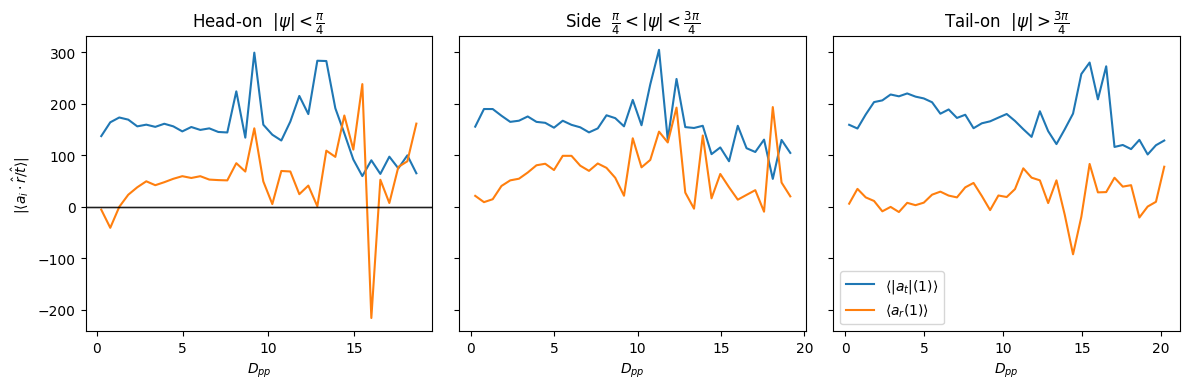

In [404]:
bins_a_f = np.linspace(0, np.nanmax(d_mid_f), 40)
bin_centers_a_f = 0.5 * (bins_a_f[1:] + bins_a_f[:-1])

arad_face_10_f, arad_side_10_f, arad_tail_10_f = [], [], []
atan_face_10_f, atan_side_10_f, atan_tail_10_f = [], [], []

for b0, b1 in zip(bins_a_f[:-1], bins_a_f[1:]):
    in_bin_f = (d_mid_f >= b0) & (d_mid_f < b1)

    face = in_bin_f & (np.abs(psi_10_mid_f) < np.pi/4)
    side = in_bin_f & (np.abs(psi_10_mid_f) > np.pi/4) & (np.abs(psi_10_mid_f) < 3*np.pi/4)
    tail = in_bin_f & (np.abs(psi_10_mid_f) > 3*np.pi/4)

    arad_face_10_f.append(np.nanmean(a_rad10_f[face]))
    arad_side_10_f.append(np.nanmean(a_rad10_f[side]))
    arad_tail_10_f.append(np.nanmean(a_rad10_f[tail]))

    atan_face_10_f.append(np.nanmean(np.abs(a_tan10_f[face])))
    atan_side_10_f.append(np.nanmean(np.abs(a_tan10_f[side])))
    atan_tail_10_f.append(np.nanmean(np.abs(a_tan10_f[tail])))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(12,4))

K = 40 
ax1.plot(bin_centers_a_f, atan_face_10_f, label=r'$\langle |a_t|(1) \rangle$')
ax1.plot(bin_centers_a_f, arad_face_10_f, label=r'$\langle a_r(1) \rangle$')
ax1.set_title(r"Head-on  $|\psi|<\frac{\pi}{4}$")
ax1.set_xlabel(r"$D_{pp}$")
ax1.set_ylabel(r"$|\langle a_i \cdot \hat{r}/\hat{t} \rangle|$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax2.plot(bin_centers_a_f, atan_side_10_f)
ax2.plot(bin_centers_a_f, arad_side_10_f)
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|<\frac{3\pi}{4}$")
ax2.set_xlabel(r"$D_{pp}$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax3.plot(bin_centers_a_f, atan_tail_10_f,label=r'$\langle |a_t|(1) \rangle$')
ax3.plot(bin_centers_a_f, arad_tail_10_f, label=r'$\langle a_r(1) \rangle$')
ax1.axhline(0, color='k', lw=1, alpha=0.5)
ax3.set_title(r"Tail-on  $|\psi|>\frac{3\pi}{4}$")
ax3.set_xlabel(r"$D_{pp}$")
ax3.legend()

fig.tight_layout()
plt.show()

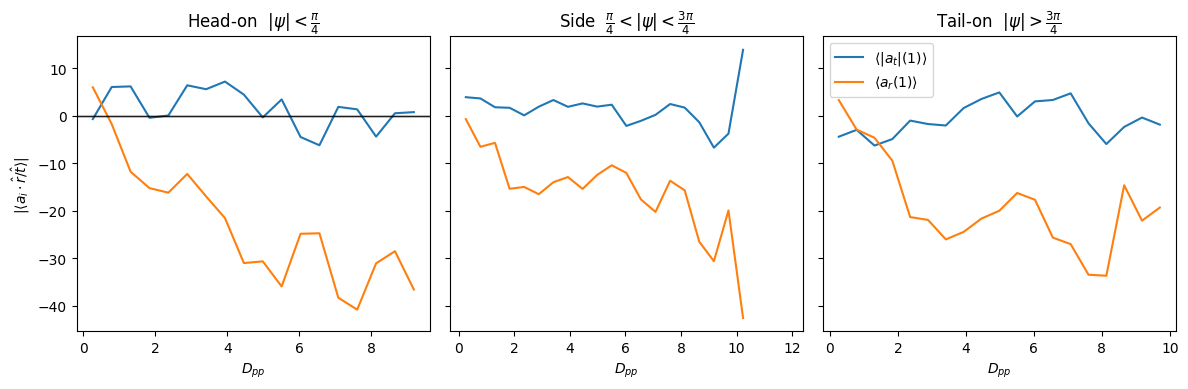

In [411]:
win = 21      
poly = 3

x0 = pec_fish0_f[:,0]
y0 = pec_fish0_f[:,1]

vx0 = savgol_filter(x0, win, poly, deriv=1, delta=dt)
ax0 = savgol_filter(x0, win, poly, deriv=2, delta=dt)

vy0 = savgol_filter(y0, win, poly, deriv=1, delta=dt)
ay0 = savgol_filter(y0, win, poly, deriv=2, delta=dt)

x1 = pec_fish1_f[:,0]
y1 = pec_fish1_f[:,1]

vx1 = savgol_filter(x0, win, poly, deriv=1, delta=dt)
ax1 = savgol_filter(x0, win, poly, deriv=2, delta=dt)

vy1 = savgol_filter(y0, win, poly, deriv=1, delta=dt)
ay1 = savgol_filter(y0, win, poly, deriv=2, delta=dt)

a0_f_smooth = np.stack([ax0, ay0], axis=1)
a1_f_smooth = np.stack([ax1, ay1], axis=1)



r01_mid_f = pec_fish1_f[1:-1] - pec_fish0_f[1:-1] 
r01_xy = r01_mid_f[:, :2]
d_mid_f = np.linalg.norm(r01_mid_f[:, :2], axis=1)

r_hat01_f = r01_xy / np.linalg.norm(r01_xy, axis=1, keepdims=True)  
r_hat10_f = -r_hat01_f

t_hat01_f = np.stack([-r_hat01_f[:,1], r_hat01_f[:,0]], axis=1)
t_hat10_f = -t_hat01_f

a_rad01_f = np.sum(a0_f_smooth[1:-1, :2] * r_hat01_f, axis=1)         
a_rad10_f = np.sum(a1_f_smooth[1:-1, :2] * r_hat10_f, axis=1)   
a_tan01_f = np.sum(a0_f_smooth[1:-1, :2] * t_hat01_f, axis=1)  
a_tan10_f = np.sum(a1_f_smooth[1:-1, :2] * t_hat10_f, axis=1)

psi_01_mid_f = psi_01_f[1:-1]
psi_10_mid_f = psi_10_f[1:-1]


bins_a_f = np.linspace(0, np.nanmax(d_mid_f), 40)
bin_centers_a_f = 0.5 * (bins_a_f[1:] + bins_a_f[:-1])

arad_face_10_f, arad_side_10_f, arad_tail_10_f = [], [], []
atan_face_10_f, atan_side_10_f, atan_tail_10_f = [], [], []

for b0, b1 in zip(bins_a_f[:-1], bins_a_f[1:]):
    in_bin_f = (d_mid_f >= b0) & (d_mid_f < b1)

    face = in_bin_f & (np.abs(psi_10_mid_f) < np.pi/4)
    side = in_bin_f & (np.abs(psi_10_mid_f) > np.pi/4) & (np.abs(psi_10_mid_f) < 3*np.pi/4)
    tail = in_bin_f & (np.abs(psi_10_mid_f) > 3*np.pi/4)

    min_count = 100  # tune
    cnt_f = np.sum(face)
    cnt_s = np.sum(side)
    cnt_t = np.sum(tail)

    arad_face_10_f.append(np.nan if cnt_f < min_count else(np.nanmean(a_rad10_f[face])))
    arad_side_10_f.append(np.nan if cnt_s < min_count else(np.nanmean(a_rad10_f[side])))
    arad_tail_10_f.append(np.nan if cnt_t < min_count else(np.nanmean(a_rad10_f[tail])))

    atan_face_10_f.append(np.nan if cnt_f < min_count else(np.nanmean(a_tan10_f[face])))
    atan_side_10_f.append(np.nan if cnt_s < min_count else(np.nanmean(a_tan10_f[side])))
    atan_tail_10_f.append(np.nan if cnt_t < min_count else(np.nanmean(a_tan10_f[tail])))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(12,4))

K = 40  # to mimic your [0:30] cutoff
ax1.plot(bin_centers_a_f[:K], atan_face_10_f[:K], label=r'$\langle |a_t|(1) \rangle$')
ax1.plot(bin_centers_a_f[:K], arad_face_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.set_title(r"Head-on  $|\psi|<\frac{\pi}{4}$")
ax1.set_xlabel(r"$D_{pp}$")
ax1.set_ylabel(r"$|\langle a_i \cdot \hat{r}/\hat{t} \rangle|$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax2.plot(bin_centers_a_f[:K], atan_side_10_f[:K])
ax2.plot(bin_centers_a_f[:K], arad_side_10_f[:K])
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|<\frac{3\pi}{4}$")
ax2.set_xlabel(r"$D_{pp}$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax3.plot(bin_centers_a_f[:K], atan_tail_10_f[:K],label=r'$\langle |a_t|(1) \rangle$')
ax3.plot(bin_centers_a_f[:K], arad_tail_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.axhline(0, color='k', lw=1, alpha=0.5)
ax3.set_title(r"Tail-on  $|\psi|>\frac{3\pi}{4}$")
ax3.set_xlabel(r"$D_{pp}$")
ax3.legend()

fig.tight_layout()
plt.show()

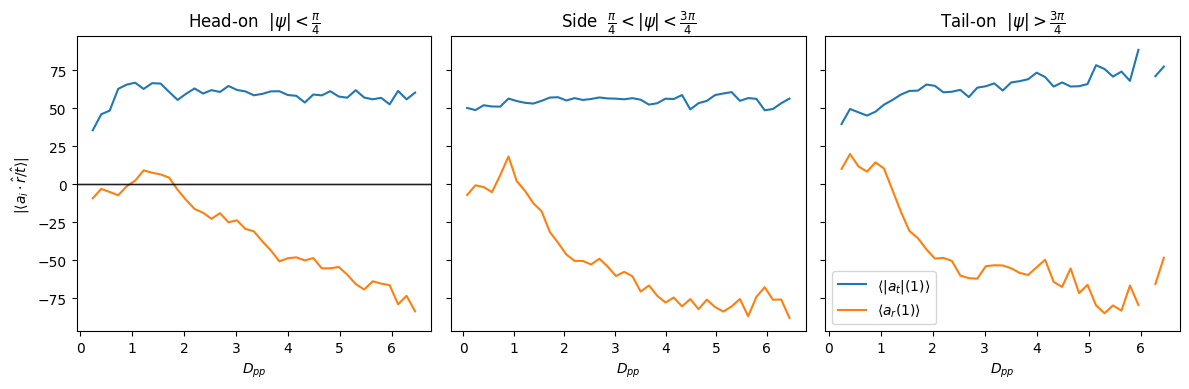

In [439]:
win = 21      
poly = 3

x0 = pec_fish0_f[:,0]
y0 = pec_fish0_f[:,1]

vx0 = savgol_filter(x0, win, poly, deriv=1, delta=dt)
ax0 = savgol_filter(x0, win, poly, deriv=2, delta=dt)

vy0 = savgol_filter(y0, win, poly, deriv=1, delta=dt)
ay0 = savgol_filter(y0, win, poly, deriv=2, delta=dt)

x1 = pec_fish1_f[:,0]
y1 = pec_fish1_f[:,1]

vx1 = savgol_filter(x1, win, poly, deriv=1, delta=dt)
ax1 = savgol_filter(x1, win, poly, deriv=2, delta=dt)

vy1 = savgol_filter(y1, win, poly, deriv=1, delta=dt)
ay1 = savgol_filter(y1, win, poly, deriv=2, delta=dt)

a0_f_smooth = np.stack([ax0, ay0], axis=1)
a1_f_smooth = np.stack([ax1, ay1], axis=1)

arel = a1_f_smooth - a0_f_smooth

r01_mid_f = pec_fish1_f[1:-1] - pec_fish0_f[1:-1] 
r01_xy = r01_mid_f[:, :2]
d_mid_f = np.linalg.norm(r01_mid_f[:, :2], axis=1)

r_hat01_f = r01_xy / np.linalg.norm(r01_xy, axis=1, keepdims=True)  
r_hat10_f = -r_hat01_f

t_hat01_f = np.stack([-r_hat01_f[:,1], r_hat01_f[:,0]], axis=1)
t_hat10_f = -t_hat01_f

a_rad01_f = np.sum(a0_f_smooth[1:-1, :2] * r_hat01_f, axis=1)         
a_rad10_f = np.sum(a1_f_smooth[1:-1, :2] * r_hat10_f, axis=1)   
a_tan01_f = np.sum(a0_f_smooth[1:-1, :2] * t_hat01_f, axis=1)  
a_tan10_f = np.sum(a1_f_smooth[1:-1, :2] * t_hat10_f, axis=1)
a_rad_rel_01f = np.sum(arel[1:-1, :2] * r_hat01_f, axis=1)  
a_tan_rel_01f = np.sum(arel[1:-1, :2] * t_hat01_f, axis=1)  
a_rad_rel_10f = np.sum(-arel[1:-1,:2] * r_hat10_f, axis=1)
a_tan_rel_10f = np.sum(-arel[1:-1,:2] * t_hat10_f, axis=1)


psi_01_mid_f = psi_01_f[1:-1]
psi_10_mid_f = psi_10_f[1:-1]

bins_a_f = np.linspace(0, 8, 50)
bin_centers_a_f = 0.5 * (bins_a_f[1:] + bins_a_f[:-1])

arad_face_10_f, arad_side_10_f, arad_tail_10_f = [], [], []
atan_face_10_f, atan_side_10_f, atan_tail_10_f = [], [], []

for b0, b1 in zip(bins_a_f[:-1], bins_a_f[1:]):
    in_bin_f = (d_mid_f >= b0) & (d_mid_f < b1)

    face = in_bin_f & (np.abs(psi_01_mid_f) < np.pi/4)
    side = in_bin_f & (np.abs(psi_01_mid_f) > np.pi/4) & (np.abs(psi_01_mid_f) < 3*np.pi/4)
    tail = in_bin_f & (np.abs(psi_01_mid_f) > 3*np.pi/4)

    min_count = 100  # tune
    cnt_f = np.sum(face)
    cnt_s = np.sum(side)
    cnt_t = np.sum(tail)

    arad_face_10_f.append(np.nan if cnt_f < min_count else(np.nanmean(a_rad_rel_01f[face])))
    arad_side_10_f.append(np.nan if cnt_s < min_count else(np.nanmean(a_rad_rel_01f[side])))
    arad_tail_10_f.append(np.nan if cnt_t < min_count else(np.nanmean(a_rad_rel_01f[tail])))

    atan_face_10_f.append(np.nan if cnt_f < min_count else(np.nanmean(np.abs(a_tan_rel_01f[face]))))
    atan_side_10_f.append(np.nan if cnt_s < min_count else(np.nanmean(np.abs(a_tan_rel_01f[side]))))
    atan_tail_10_f.append(np.nan if cnt_t < min_count else(np.nanmean(np.abs(a_tan_rel_01f[tail]))))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(12,4))

K = 40  # to mimic your [0:30] cutoff
ax1.plot(bin_centers_a_f[:K], atan_face_10_f[:K], label=r'$\langle |a_t|(1) \rangle$')
ax1.plot(bin_centers_a_f[:K], arad_face_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.set_title(r"Head-on  $|\psi|<\frac{\pi}{4}$")
ax1.set_xlabel(r"$D_{pp}$")
ax1.set_ylabel(r"$|\langle a_i \cdot \hat{r}/\hat{t} \rangle|$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax2.plot(bin_centers_a_f[:K], atan_side_10_f[:K])
ax2.plot(bin_centers_a_f[:K], arad_side_10_f[:K])
ax2.set_title(r"Side  $\frac{\pi}{4}<|\psi|<\frac{3\pi}{4}$")
ax2.set_xlabel(r"$D_{pp}$")
ax1.axhline(0, color='k', lw=1, alpha=0.5)

ax3.plot(bin_centers_a_f[:K], atan_tail_10_f[:K],label=r'$\langle |a_t|(1) \rangle$')
ax3.plot(bin_centers_a_f[:K], arad_tail_10_f[:K], label=r'$\langle a_r(1) \rangle$')
ax1.axhline(0, color='k', lw=1, alpha=0.5)
ax3.set_title(r"Tail-on  $|\psi|>\frac{3\pi}{4}$")
ax3.set_xlabel(r"$D_{pp}$")
ax3.legend()

fig.tight_layout()
plt.show()

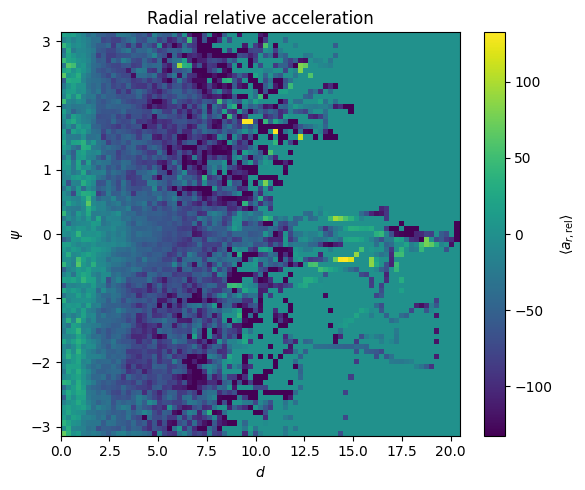

In [446]:
mask = np.isfinite(d_mid_f) & np.isfinite(psi_01_mid_f) & np.isfinite(a_rad_rel_01f)

d = d_mid_f[mask]
psi = psi_01_mid_f[mask]
a = a_rad_rel_01f[mask]

# define bins
d_bins = np.linspace(0, np.nanmax(d), 80)
psi_bins = np.linspace(-np.pi, np.pi, 80)

sum_a, _, _ = np.histogram2d(d, psi, bins=[d_bins, psi_bins], weights=a)
counts, _, _ = np.histogram2d(d, psi, bins=[d_bins, psi_bins])

mean_a = sum_a / np.maximum(counts, 1)

v = np.nanpercentile(np.abs(mean_a), 95)
plt.figure(figsize=(6,5))
plt.pcolormesh(d_bins, psi_bins, mean_a.T, shading='auto', vmin=-v, vmax=v)
plt.colorbar(label=r'$\langle a_{r,\mathrm{rel}}\rangle$')
plt.xlabel(r'$d$')
plt.ylabel(r'$\psi$')
plt.title('Radial relative acceleration')
plt.tight_layout()
plt.show()

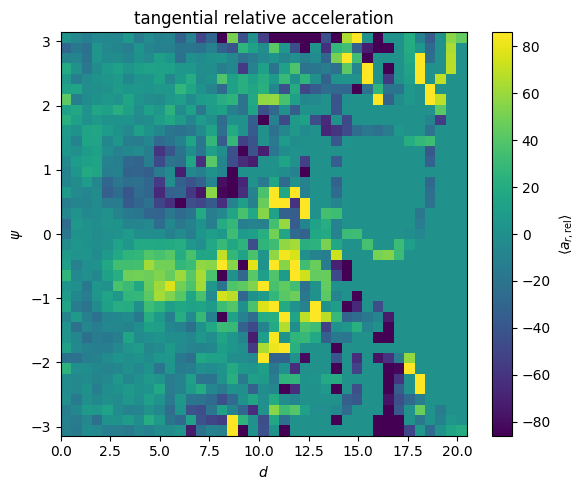

In [443]:

mask = np.isfinite(d_mid_f) & np.isfinite(psi_10_mid_f) & np.isfinite(a_tan_rel_10f)

d = d_mid_f[mask]
psi = psi_10_mid_f[mask]
a = a_tan_rel_10f[mask]

d_bins = np.linspace(0, np.nanmax(d), 40)
psi_bins = np.linspace(-np.pi, np.pi, 40)

sum_a, _, _ = np.histogram2d(d, psi, bins=[d_bins, psi_bins], weights=a)
counts, _, _ = np.histogram2d(d, psi, bins=[d_bins, psi_bins])

mean_a = sum_a / np.maximum(counts, 1)

v = np.nanpercentile(np.abs(mean_a), 95)
plt.figure(figsize=(6,5))
plt.pcolormesh(d_bins, psi_bins, mean_a.T, shading='auto', vmin=-v, vmax=v)
plt.colorbar(label=r'$\langle a_{r,\mathrm{rel}}\rangle$')
plt.xlabel(r'$d$')
plt.ylabel(r'$\psi$')
plt.title('tangential relative acceleration')
plt.tight_layout()
plt.show()